### Team 2: LSTM and CNN Composer Classification
### 511: Neural Networks and Deep Learning Final Project

## Setup and Library Installation

The dataset for this project originates from the Kaggle "MIDI Classic Music" corpus. To facilitate seamless collaboration across different cloud environments (Google Colab and Databricks) without requiring local API keys, the dataset has been hosted on a shared Google Drive. This cell uses the gdown library to securely download and extract the raw MIDI files into the local cluster's temporary storage.

In [ ]:
# Required libraries
%pip install pretty_midi music21 seaborn kaggle pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.1 MB/s eta 0:00:00


In [ ]:
# Imports
%pip install gdown
import gdown
import os
import zipfile

# Define paths
data_dir = "./data/midi_data"
os.makedirs(data_dir, exist_ok=True)
zip_path = os.path.join(data_dir, "midi-classic-music.zip")

# Download from Google Drive
file_id = '1QJPbVi6q2QPIiD47ZBf9tDxhM4ON-7mj'
# Corrected URL for direct download
url = f'https://drive.google.com/uc?id={file_id}'

print("Downloading dataset from Google Drive...")
gdown.download(url, zip_path, quiet=False)

# Unzip the file
print(f"\nExtracting {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

print(f"Extraction complete! Files are located in: {data_dir}")

import os
print(os.listdir("./data/midi_data"))

import os

target_composers = ["Bach", "Beethoven", "Chopin", "Mozart"]
data_dir = "./data/midi_data"

for composer in target_composers:
    composer_path = os.path.join(data_dir, composer)
    if os.path.exists(composer_path):
        file_count = len([f for f in os.listdir(composer_path) if f.endswith('.mid')])
        print(f"{composer}: {file_count} MIDI files")
    else:
        print(f"{composer}: folder not found — check exact name")

Downloading...
From (original): https://drive.google.com/uc?id=1QJPbVi6q2QPIiD47ZBf9tDxhM4ON-7mj
From (redirected): https://drive.google.com/uc?id=1QJPbVi6q2QPIiD47ZBf9tDxhM4ON-7mj&confirm=t&uuid=630a68ea-90bb-41ad-8d8c-170cf22e9b88
To: /content/data/midi_data/midi-classic-music.zip
100%|██████████| 36.4M/36.4M [00:00<00:00, 51.9MB/s]



Extracting ./data/midi_data/midi-classic-music.zip...
Extraction complete! Files are located in: ./data/midi_data
['Resch', 'Kuhlau Sonatina op55 n3 1mov.mid', 'Vivaldi', 'Schoenberg', 'Haendel', 'Friedman', 'Diabelli Sonatina op151 n3 2mov.mid', 'Shostakovich', 'Scarlatti', 'Bartelet', 'Liszt Paganini Etude n1.mid', 'Ivanovici', 'Burgmuller', 'Heller', 'Buxethude Buxwv156 Toccata.mid', 'Coleridge-Taylor', 'Lange', 'Buxethude Buxwv160 Ciacona.mid', 'Finck', 'Haydn', 'Rothchild Oboe Concerto Rmw09 1mov.mid', 'Diabelli Sonatina op151 n2 2mov.mid', 'Bartok', 'Varios - Título desconocido', 'Sarasate', 'Beethoven', 'Debussy Suite Bergamasque 4mov.mid', 'Hemery', 'Alkan', 'Chaminade', 'Grainger', 'Peterson-Berger', 'Durand, E', 'Wolf', 'C.P.E.Bach Solfeggieto.mid', 'Satie', 'Dvorak Trio op26.mid', 'Lecuona', 'Diabelli Sonatina op151 n4 2mov.mid', 'Sibelius Kuolema Vals op44.mid', 'Dussek', 'Coates', 'Tchaikovsky Lake Of The Swans Act 2 11mov.mid', 'Katzwarra', 'Schumann', 'Saint-Saens', 'W

## Data Filtering

The original corpus contains compositions from 175 different composers. Per the project requirements, our predictive models will focus on classifying four specific classical masters: **Bach, Beethoven, Chopin, and Mozart**.

This script iterates through the extracted directory, retains only the target composers, and removes the remaining directories to optimize storage and memory usage.

In [ ]:
# Filter for specific composers
import os
import shutil

target_composers = ['bach', 'beethoven', 'chopin', 'mozart']

# Find where the composer folders are
base_midi_path = data_dir
if "midi_classic_music" in os.listdir(data_dir):
    base_midi_path = os.path.join(data_dir, "midi_classic_music")

all_folders = [f for f in os.listdir(base_midi_path) if os.path.isdir(os.path.join(base_midi_path, f))]
print(f"Found {len(all_folders)} total composer folders.")

# Delete non-target folders
removed_count = 0
for folder in all_folders:
    # Use lowercase for safer string matching
    if folder.lower() not in target_composers:
        shutil.rmtree(os.path.join(base_midi_path, folder))
        removed_count += 1

print(f"Removed {removed_count} folders. Kept target composers only.")

Found 138 total composer folders.
Removed 134 folders. Kept target composers only.


## Data Cleaning

Raw data scraped from the internet frequently contains corrupted, truncated, or empty files. Feeding invalid files into deep learning pipelines causes fatal runtime errors during feature extraction.

This cell acts as a quality control gateway: it attempts to parse every `.mid` and `.midi` file using `pretty_midi`, automatically deleting files that are structurally unreadable or contain zero musical notes.

Before exploring or training on the data, we must address class imbalance. If one composer has 1,000 files and another has only 200, our CNN and LSTM models may simply learn to always predict the majority class.

This step calculates the size of the smallest composer class and randomly undersamples the majority classes to match it. A fixed random seed (`42`) is utilized to guarantee that all team members generate the exact same balanced dataset.

In [ ]:
# Data Cleaning Pipeline
import pretty_midi
import glob
from tqdm import tqdm
import random
import os
from collections import Counter

# Find all .mid and .midi files in the remaining folders
midi_files = glob.glob(f"{base_midi_path}/**/*.mid", recursive=True) + \
             glob.glob(f"{base_midi_path}/**/*.midi", recursive=True)

print(f"Found {len(midi_files)} potential MIDI files for our 4 composers.")

valid_files = []
corrupt_files = []

# Loop and validate
for file_path in tqdm(midi_files, desc="Validating MIDI files"):
    try:
        # Parse the MIDI file
        midi_data = pretty_midi.PrettyMIDI(file_path)

        # Check if the file contains instruments/notes
        if len(midi_data.instruments) == 0:
            raise ValueError("No instruments found.")

        total_notes = sum(len(instrument.notes) for instrument in midi_data.instruments)
        if total_notes == 0:
            raise ValueError("No notes found.")

        # Add to valid list if it passes
        valid_files.append(file_path)

    except Exception as e:
        corrupt_files.append((file_path, str(e)))
        # Delete the bad file
        os.remove(file_path)

print(f"\nCleaning Summary")
print(f"Valid Files: {len(valid_files)}")
print(f"Corrupt/Empty Files Removed: {len(corrupt_files)}")
if corrupt_files:
    print(f"Example error: {corrupt_files[0]}")

# Handling Class Imbalance via Undersampling
# Group valid files by composer
composer_files = {composer: [] for composer in target_composers}
composer_counts = Counter()

for file_path in valid_files:
    # Extract composer name from the folder path and lowercase it
    composer = os.path.basename(os.path.dirname(file_path)).lower()
    if composer in target_composers:
        composer_files[composer].append(file_path)
        composer_counts[composer] += 1

print("Original Clean File Counts")
for comp, count in composer_counts.items():
    print(f"{comp.capitalize()}: {count}")

# Minimum class size
min_class_size = min(composer_counts.values())
print(f"\nBalancing dataset to {min_class_size} files per composer")

# Randomly undersample the majority classes
balanced_valid_files = []

# Random seed so everyone gets the exact same files every time it runs
random.seed(42)

for composer, files in composer_files.items():
    # Randomly select 'min_class_size' files from this composer's list
    sampled_files = random.sample(files, min_class_size)
    balanced_valid_files.extend(sampled_files)

print(f"\nBalanced Dataset Summary")
print(f"Total Balanced Files: {len(balanced_valid_files)}")

# Overwrite the original valid_files list
valid_files = balanced_valid_files

Found 1630 potential MIDI files for our 4 composers.


Validating MIDI files:   0%|          | 0/1630 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Validating MIDI files: 100%|██████████| 1630/1630 [03:30<00:00,  7.76it/s]


Cleaning Summary
Valid Files: 1626
Corrupt/Empty Files Removed: 4
Example error: ('./data/midi_data/Buxethude Buxwv161 Passcaglia.mid', 'list index out of range')
Original Clean File Counts
Beethoven: 132
Bach: 122
Mozart: 90
Chopin: 136

Balancing dataset to 90 files per composer

Balanced Dataset Summary
Total Balanced Files: 360


## **Exploratory Data Analysis (EDA)**

Before transforming the MIDI files into high-dimensional sequences (for the LSTM) or 2D piano-roll matrices (for the CNN), we extract high-level statistical features to understand the underlying distributions.

This script loops through the balanced dataset and extracts metrics such as composition length, note density (notes per second), estimated tempo (BPM), and average pitch.

In [ ]:
# EDA metrics
import pandas as pd
import numpy as np

eda_data = []

for file_path in tqdm(valid_files, desc="Extracting EDA Features"):
    try:
        composer = os.path.basename(os.path.dirname(file_path)).capitalize()
        midi_data = pretty_midi.PrettyMIDI(file_path)

        # Total length of piece in seconds
        length_sec = midi_data.get_end_time()

        # Total number of notes across all tracks
        total_notes = sum(len(instrument.notes) for instrument in midi_data.instruments)

        # Estimated Tempo (BPM)
        tempo = midi_data.estimate_tempo()

        # Average pitch and pitch range
        all_pitches = []
        for instrument in midi_data.instruments:
            # Ignoring drum tracks for this analysis
            if not instrument.is_drum:
                all_pitches.extend([note.pitch for note in instrument.notes])

        if all_pitches:
            avg_pitch = np.mean(all_pitches)
            pitch_range = np.max(all_pitches) - np.min(all_pitches)
        else:
            avg_pitch = 0
            pitch_range = 0

        # Append to list
        eda_data.append({
            "Composer": composer,
            "Length_Seconds": length_sec,
            "Total_Notes": total_notes,
            "Notes_Per_Second": total_notes / length_sec if length_sec > 0 else 0,
            "Estimated_BPM": tempo,
            "Average_Pitch": avg_pitch,
            "Pitch_Range": pitch_range
        })
    except Exception:
        continue  # Skip files that act up during deep extraction

df_eda = pd.DataFrame(eda_data)
display(df_eda.head())

Extracting EDA Features:   2%|▎         | 9/360 [00:04<02:14,  2.61it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Extracting EDA Features: 100%|██████████| 360/360 [01:06<00:00,  5.39it/s]


,Composer,Length_Seconds,Total_Notes,Notes_Per_Second,Estimated_BPM,Average_Pitch,Pitch_Range
0,Bach,618.158060,4421,7.151893,160.827960,64.347659,44
1,Bach,745.165200,4493,6.029535,246.250401,63.583352,48
2,Bach,515.662760,3367,6.529461,218.689311,64.756460,46
3,Bach,857.375929,20062,23.399304,260.798348,65.825740,72
4,Bach,682.367570,5930,8.690331,164.093996,67.226644,48


## **Visualization**

Using the extracted features, this cell generates a series of visualizations to explore structural differences between the four composers.

By analyzing note density, piece length, and tempo distributions, we can visually identify if certain composers have distinct stylistic signatures that our neural networks will likely rely on for classification.

/tmp/ipykernel_2557/1593933281.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x="Composer", palette="viridis")
/tmp/ipykernel_2557/1593933281.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="Composer", y="Notes_Per_Second", palette="viridis")
/tmp/ipykernel_2557/1593933281.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_eda, x="Composer", y="Length_Seconds", palette="viridis")


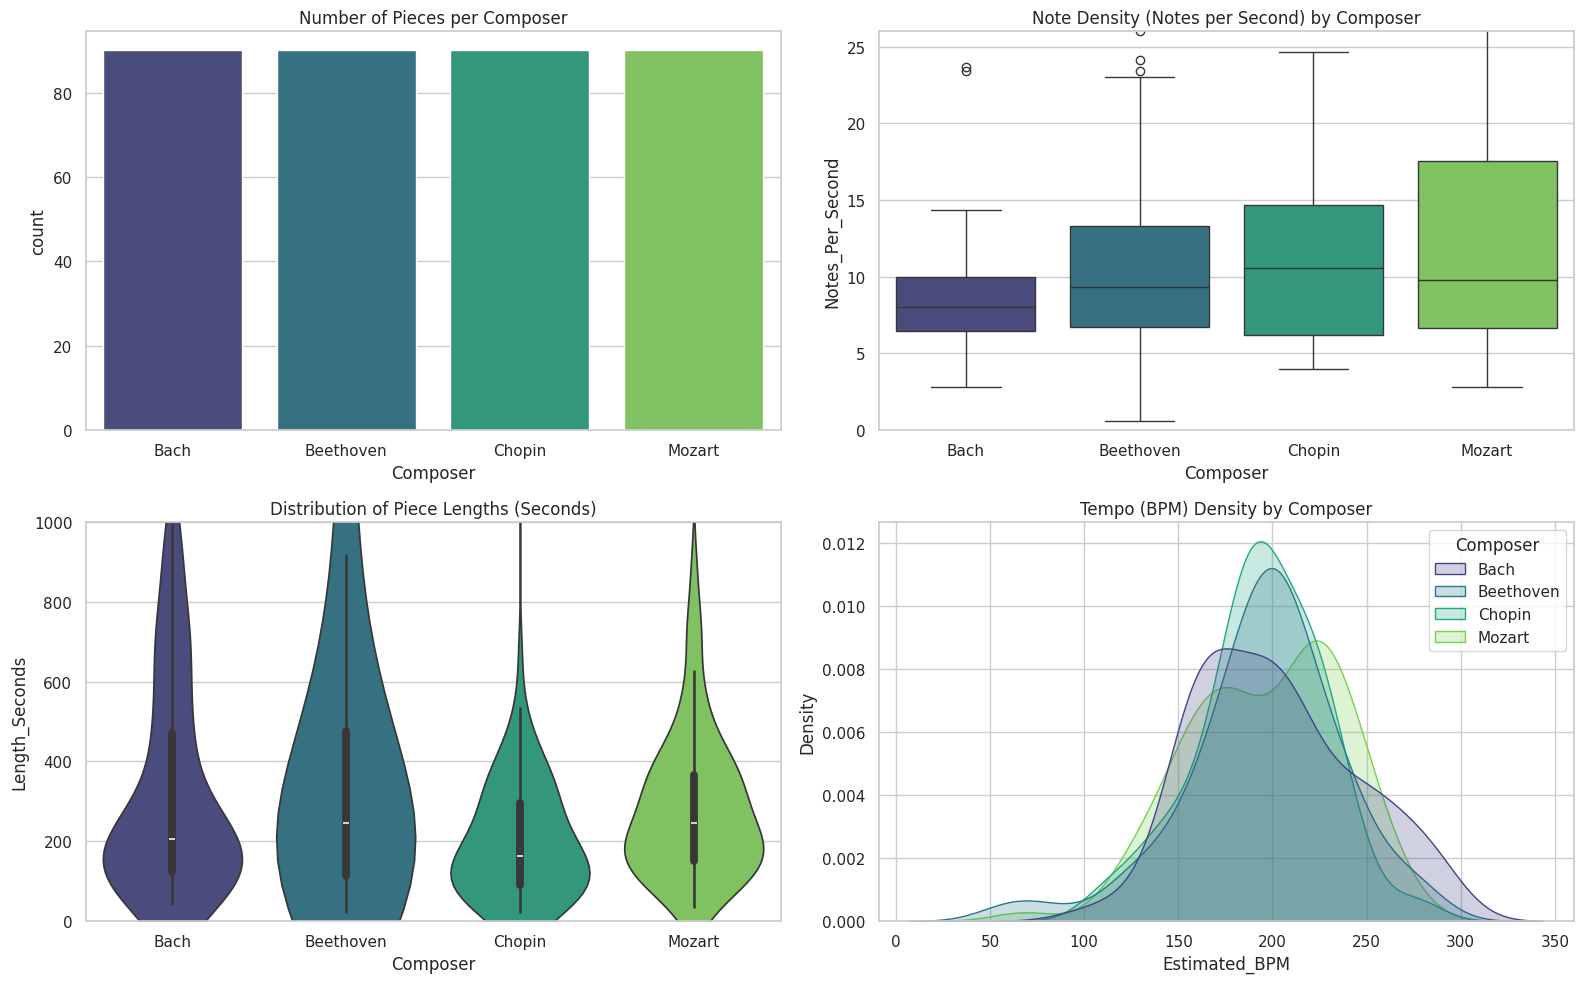

In [ ]:
# Plotting the Data
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# Distribution of Classes (Imbalance check)
plt.subplot(2, 2, 1)
sns.countplot(data=df_eda, x="Composer", palette="viridis")
plt.title("Number of Pieces per Composer")

# Notes per Second (Complexity/Density)
plt.subplot(2, 2, 2)
sns.boxplot(data=df_eda, x="Composer", y="Notes_Per_Second", palette="viridis")
plt.title("Note Density (Notes per Second) by Composer")
plt.ylim(0, df_eda["Notes_Per_Second"].quantile(0.95))

# Piece Lengths
plt.subplot(2, 2, 3)
sns.violinplot(data=df_eda, x="Composer", y="Length_Seconds", palette="viridis")
plt.title("Distribution of Piece Lengths (Seconds)")
plt.ylim(0, 1000)

# Estimated Tempo
plt.subplot(2, 2, 4)
sns.kdeplot(data=df_eda, x="Estimated_BPM", hue="Composer", fill=True, palette="viridis", common_norm=False)
plt.title("Tempo (BPM) Density by Composer")

plt.tight_layout()
plt.show()

###**Observation on the Data:**

@Christian To include comment here

**Next Steps:**
We will evaluate the classification task using two models:

1 - LSTM

2 - CNN

### **LONG SHORT-TERM MEMORY (LSTM)**
Recurrent Neural Netwwork (RNN) Model



In [ ]:
# LSTM Feature Extraction with Time Stretching Augmentation
# Converts each MIDI file into a sequence of note/chord "tokens" using music21.
# Each token represents either a single note (pitch) or a chord (multiple pitches
# played together), which the LSTM will learn sequential patterns from.
#
# AUGMENTATION: For each file, we also create time-stretched versions (0.9x and 1.1x)
# to help the model handle Mozart's wide variability in notes-per-second (4-24 range).

from music21 import converter, note, chord
from tqdm import tqdm
import glob
import copy
import os  # Added import os

# Reconstruct valid_files if it doesn't exist (e.g., after kernel restart)
if 'valid_files' not in dir():
    print("Reconstructing valid_files from filesystem...")
    data_dir = "./data/midi_data"  # Re-define data_dir
    os.makedirs(data_dir, exist_ok=True)  # Ensure data_dir exists
    base_midi_path = data_dir
    if "midi_classic_music" in os.listdir(data_dir):
        base_midi_path = os.path.join(data_dir, "midi_classic_music")

    valid_files = glob.glob(f"{base_midi_path}/**/*.mid", recursive=True) + \
                  glob.glob(f"{base_midi_path}/**/*.midi", recursive=True)
    print(f"Found {len(valid_files)} MIDI files from filesystem")

def time_stretch_midi(midi_obj, factor):
    """Apply time stretching by scaling all note durations."""
    stretched = copy.deepcopy(midi_obj)
    for element in stretched.flat.notes:
        element.quarterLength *= factor
    return stretched

def extract_note_sequence(midi_obj):
    """Parse a MIDI object and return a list of note/chord tokens."""
    notes_to_parse = None

    parts = midi_obj.getElementsByClass('Part')
    if parts:
        notes_to_parse = parts[0].recurse()
    else:
        notes_to_parse = midi_obj.flat.notes

    sequence = []
    for element in notes_to_parse:
        if isinstance(element, note.Note):
            sequence.append(str(element.pitch))
        elif isinstance(element, chord.Chord):
            sequence.append('.'.join(str(n) for n in element.normalOrder))

    return sequence

# Run extraction with time stretching augmentation
lstm_data = []  # list of (composer, sequence) tuples
failed_files = []
time_stretch_factors = [0.9, 1.0, 1.1]  # 0.9x (faster), original, 1.1x (slower)

for file_path in tqdm(valid_files, desc="Extracting sequences with time stretching"):
    try:
        composer = os.path.basename(os.path.dirname(file_path)).capitalize()

        # Parse the original MIDI file once
        midi_original = converter.parse(file_path)

        # Extract sequences for each time-stretched version
        for factor in time_stretch_factors:
            if factor == 1.0:
                # Use original without copying
                midi_obj = midi_original
            else:
                # Apply time stretching
                midi_obj = time_stretch_midi(midi_original, factor)

            sequence = extract_note_sequence(midi_obj)
            if len(sequence) > 0:
                lstm_data.append((composer, sequence))

    except Exception as e:
        failed_files.append((file_path, str(e)))
        continue

print(f"\nSuccessfully extracted sequences from {len(lstm_data)} augmented versions")
print(f"  (Original files: {len(valid_files)}), Augmentation factor: {len(time_stretch_factors)}x)")
print(f"Failed to extract: {len(failed_files)} files")
if failed_files:
    print(f"Example failure: {failed_files[0]}")

Extracting sequences with time stretching:   0%|          | 0/360 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
Extracting sequences with time stretching:  11%|█▏        | 41/360 [05:54<22:13,  4.18s/it]/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Preludiul nr.3 \xeen re minor, BWV 935'>; getting generic Instrument
  warnings.warn(
Extracting sequences with time stretching:  26%|██▋       | 95/360 [11:17<19:38,  4.45s/it]/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Concerto pour violon et orchestre en R\xe9 majeur'>; getting generic Instrument


Successfully extracted sequences from 1080 augmented versions
  (Original files: 360), Augmentation factor: 3x)
Failed to extract: 0 files


In [ ]:
# =============================================================================
# LSTM SEQUENCE ENCODING
# =============================================================================

# LSTM Sequence Encoding
# Builds a vocabulary of all unique note/chord tokens seen across the dataset,
# then converts each sequence into a list of integers the LSTM can consume.

from collections import Counter

# Build vocabulary from all sequences
all_tokens = [token for (composer, sequence) in lstm_data for token in sequence]
token_counts = Counter(all_tokens)
vocab = sorted(token_counts.keys())

token_to_int = {token: i for i, token in enumerate(vocab)}
int_to_token = {i: token for token, i in token_to_int.items()}

vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size} unique note/chord tokens")

# Encode each sequence as a list of integers
encoded_data = [(composer, [token_to_int[t] for t in sequence]) for composer, sequence in lstm_data]

# Quick sanity check
if len(encoded_data) > 0:
    print(f"\nExample encoded sequence (first 20 tokens) from a {encoded_data[0][0]} piece:")
    print(encoded_data[0][1][:20])
else:
    print("\nWARNING: No sequences were successfully encoded. Check that lstm_data contains valid sequences.")

# Check sequence length distribution (important for choosing a fixed window size next)
seq_lengths = [len(seq) for (_, seq) in encoded_data]
if len(seq_lengths) > 0:
    print(f"\nSequence length stats:")
    print(f"Min: {min(seq_lengths)}, Max: {max(seq_lengths)}, Mean: {sum(seq_lengths)/len(seq_lengths):.0f}")
else:
    print("\nNo sequences available for length analysis.")


Vocabulary size: 902 unique note/chord tokens

Example encoded sequence (first 20 tokens) from a Bach piece:
[846, 866, 873, 839, 892, 839, 873, 880, 893, 873, 839, 873, 893, 827, 840, 893, 847, 893, 827, 880]

Sequence length stats:
Min: 29, Max: 5210, Mean: 842


In [ ]:
# =============================================================================
# LSTM TRAINING DATA PREPARATION
# =============================================================================

# LSTM Training Data Preparation with Enhanced Random Cropping
# Since sequence lengths vary hugely (29 to 5210 tokens), we slice each piece
# into fixed-length windows. Each window becomes one training example, labeled
# with its composer.
#
# AUGMENTATION: Instead of systematic sliding windows, we use RANDOM cropping
# to capture Mozart's sparse AND dense sections equally (not just start-to-end).

import numpy as np
import random

SEQUENCE_LENGTH = 100  # number of tokens per training example
WINDOWS_PER_SEQUENCE = 10  # number of random windows to extract per sequence

random.seed(42)  # For reproducibility

X = []
y = []

composers_list = sorted(set(composer for composer, _ in encoded_data))
composer_to_int = {c: i for i, c in enumerate(composers_list)}

for composer, seq in encoded_data:
    label = composer_to_int[composer]

    # Skip sequences that are too short
    if len(seq) < SEQUENCE_LENGTH:
        continue

    # For sequences that are exactly SEQUENCE_LENGTH, take it once
    if len(seq) == SEQUENCE_LENGTH:
        X.append(seq)
        y.append(label)
    else:
        # Extract multiple random windows from longer sequences
        for _ in range(WINDOWS_PER_SEQUENCE):
            # Random starting position
            max_start = len(seq) - SEQUENCE_LENGTH
            start = random.randint(0, max_start)
            window = seq[start:start + SEQUENCE_LENGTH]
            X.append(window)
            y.append(label)

X = np.array(X)
y = np.array(y)

print(f"Composer label mapping: {composer_to_int}")
print(f"Total training windows generated: {len(X)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Check class balance after windowing
unique, counts = np.unique(y, return_counts=True)
for label_idx, count in zip(unique, counts):
    composer_name = composers_list[label_idx]
    print(f"  {composer_name}: {count} windows")

Composer label mapping: {'Bach': 0, 'Beethoven': 1, 'Chopin': 2, 'Mozart': 3}
Total training windows generated: 10140
X shape: (10140, 100), y shape: (10140,)
  Bach: 2670 windows
  Beethoven: 2400 windows
  Chopin: 2580 windows
  Mozart: 2490 windows


In [ ]:
# =============================================================================
# LSTM MODEL
# =============================================================================

%pip install tensorflow

# Train/Test Split + LSTM Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Split into train/test (stratified to preserve composer balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# One-hot encode labels for multi-class classification
num_classes = len(composers_list)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Build the LSTM model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=SEQUENCE_LENGTH),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Train shape: (8112, 100), Test shape: (2028, 100)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 45s 320ms/step - accuracy: 0.5044 - loss: 1.0830 - val_accuracy: 0.6272 - val_loss: 0.9259
Epoch 2/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 43s 342ms/step - accuracy: 0.6305 - loss: 0.9006 - val_accuracy: 0.6622 - val_loss: 0.8612
Epoch 3/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 40s 313ms/step - accuracy: 0.6557 - loss: 0.8738 - val_accuracy: 0.6321 - val_loss: 0.9133
Epoch 4/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 39s 310ms/step - accuracy: 0.6564 - loss: 0.8604 - val_accuracy: 0.6415 - val_loss: 0.8927
Epoch 5/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 327ms/step - accuracy: 0.6815 - loss: 0.8343 - val_accuracy: 0.6879 - val_loss: 0.8284
Epoch 6/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 42s 332ms/step - accuracy: 0.7083 - loss: 0.7780 - val_accuracy: 0.6948 - val_loss: 0.8005
Epoch 7/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 40s 312ms/step - accuracy: 0.5820 - loss: 0.9682 - val_accuracy: 0.5676 - val_loss: 0.9789
Epoch 8/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 39s 309ms/step - accuracy: 0.6056 - loss: 0

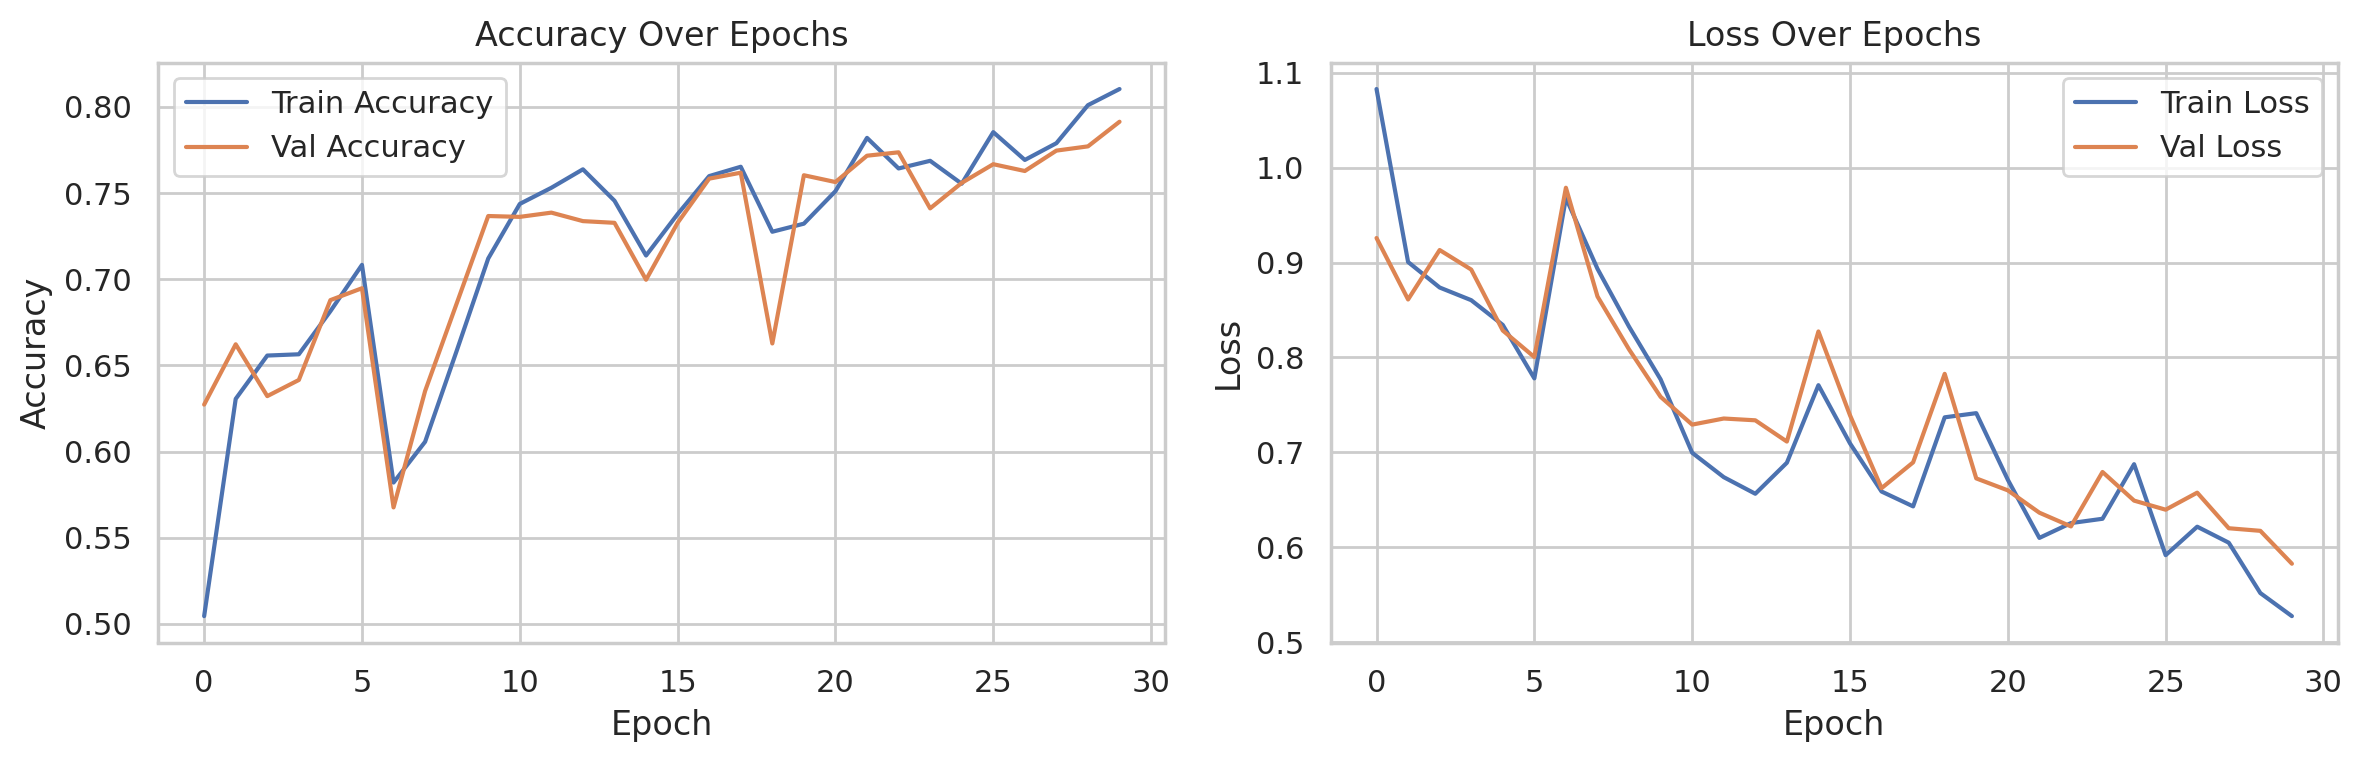

In [ ]:
# =============================================================================
# LSTM TRAINING
# =============================================================================

# Train the LSTM model
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=64,
    verbose=1
)

# =============================================================================
# LSTM TRAINING HISTORY VISUALIZATION
# =============================================================================

# Training History Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.tight_layout()
plt.show()

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step
Test Accuracy: 0.7914

Classification Report:
              precision    recall  f1-score   support

        Bach       0.71      0.84      0.77       534
   Beethoven       0.82      0.68      0.74       480
      Chopin       0.82      0.94      0.87       516
      Mozart       0.85      0.70      0.77       498

    accuracy                           0.79      2028
   macro avg       0.80      0.79      0.79      2028
weighted avg       0.80      0.79      0.79      2028


Confusion Matrix:
[[446  25  31  32]
 [ 63 326  62  29]
 [ 13  18 484   1]
 [106  29  14 349]]


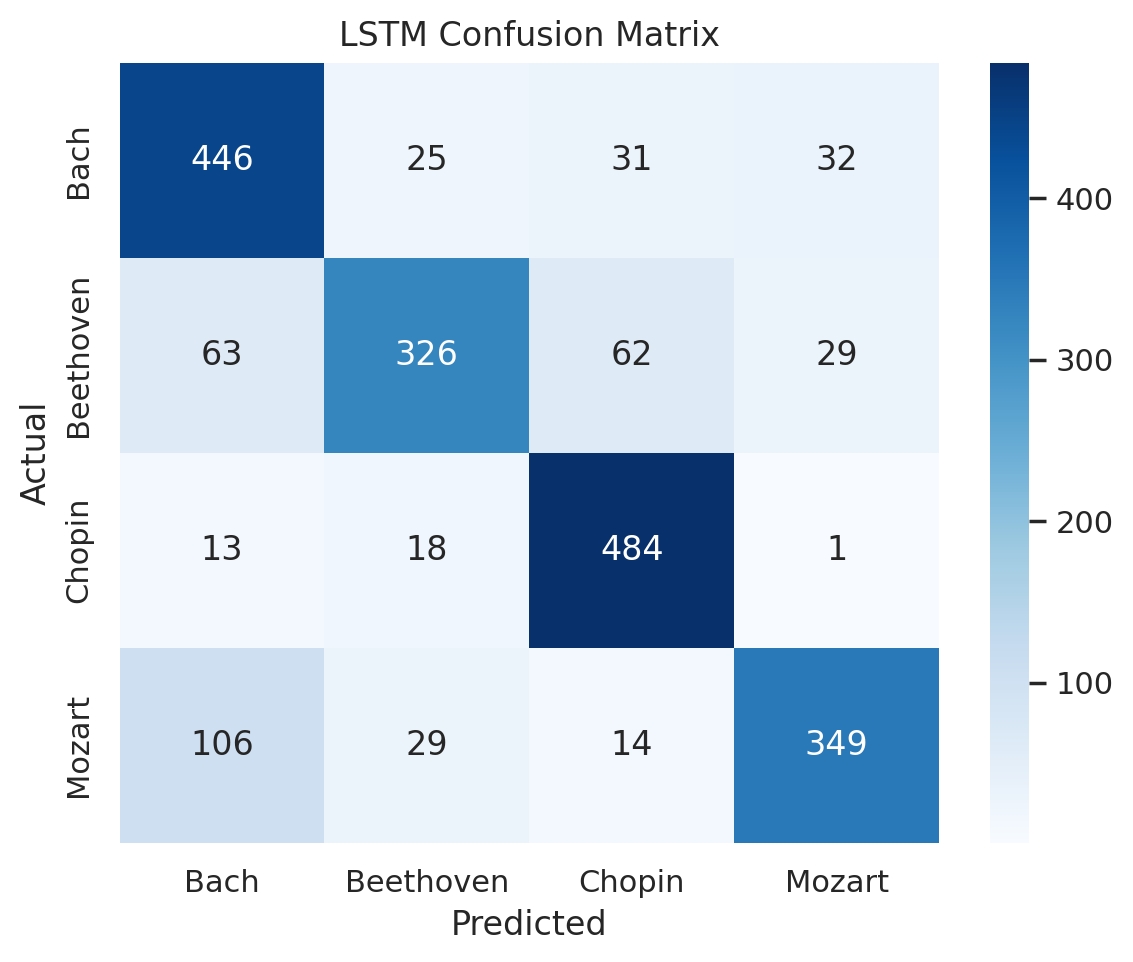

In [ ]:
# =============================================================================
# LSTM MODEL EVALUATION
# =============================================================================

# LSTM Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Predict on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Overall accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Precision, Recall, F1 per composer
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=composers_list))

# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=composers_list, yticklabels=composers_list)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.show()

# Save LSTM results for comparison later
lstm_test_accuracy = test_accuracy
lstm_y_test = y_test
lstm_y_pred = y_pred
lstm_cm = cm

###**Observation on the LSTM Model:**

@Idrees to comment here

### **CONVOLUTION NEURAL NETWORK (CNN) MODEL**

In [ ]:

# =============================================================================
# CONVOLUTION NEURAL NETWORK (CNN) MODEL
# =============================================================================

%pip install pretty_midi seaborn pandas matplotlib tqdm
%pip install tensorflow



In [ ]:
# =============================================================================
# CNN: TRAIN/TEST SPLIT SETUP
# =============================================================================

# Create train/test split sets for CNN (using same files as before)
from sklearn.model_selection import train_test_split

# Get composer labels for stratification
file_composers = [os.path.basename(os.path.dirname(f)).lower() for f in valid_files]

# Split at file level (prevents data leakage - segments from same file won't be in both train and test)
train_files, test_files = train_test_split(
    valid_files,
    test_size=0.2,
    random_state=42,
    stratify=file_composers
)

train_files_set = set(train_files)
test_files_set = set(test_files)

print(f"Train files: {len(train_files_set)}, Test files: {len(test_files_set)}")

Train files: 288, Test files: 72


In [ ]:
# =============================================================================
# CNN: PIANO ROLL CONVERSION FUNCTION
# =============================================================================

# Piano roll conversion function
import pretty_midi
import numpy as np

def midi_to_piano_roll(file_path, fps=10, pitch_min=21, pitch_max=108, normalize=True, binarize=False):
    """
    Convert a MIDI file to a piano roll matrix.

    Parameters:
    - file_path: Path to MIDI file
    - fps: Frames per second (time resolution)
    - pitch_min: Minimum MIDI pitch (A0 = 21)
    - pitch_max: Maximum MIDI pitch (C8 = 108)
    - normalize: If True, normalize velocity values to [0, 1] range
    - binarize: If True, convert to binary (note on/off only, ignoring velocity)

    Returns:
    - piano_roll: 2D array of shape (time_steps, pitch_range)
    """
    midi_data = pretty_midi.PrettyMIDI(file_path)

    # Get duration and create time grid
    duration = midi_data.get_end_time()
    time_steps = int(duration * fps)
    pitch_range = pitch_max - pitch_min + 1

    # Initialize piano roll
    piano_roll = np.zeros((time_steps, pitch_range), dtype=np.float32)

    # Fill piano roll with note velocities
    for instrument in midi_data.instruments:
        if not instrument.is_drum:  # Skip drum tracks
            for note in instrument.notes:
                # Convert time to frame indices
                start_frame = int(note.start * fps)
                end_frame = int(note.end * fps)

                # Convert pitch to piano roll row (relative to pitch_min)
                pitch_idx = note.pitch - pitch_min

                # Check if pitch is within our range
                if 0 <= pitch_idx < pitch_range:
                    # Fill the frames where this note is active with its velocity
                    piano_roll[start_frame:end_frame, pitch_idx] = note.velocity

    # Apply normalization or binarization
    if binarize:
        piano_roll = (piano_roll > 0).astype(np.float32)
    elif normalize:
        piano_roll = piano_roll / 127.0  # Normalize MIDI velocity (0-127) to [0, 1]

    return piano_roll

print("Piano roll conversion function ready.")
print(f"Piano roll dimensions: (time_steps, 88 pitches)")
print(f"Pitch range: 21 (A0) to 108 (C8)")
print(f"Time resolution: 10 fps (0.1 second per frame)")

Piano roll conversion function ready.
Piano roll dimensions: (time_steps, 88 pitches)
Pitch range: 21 (A0) to 108 (C8)
Time resolution: 10 fps (0.1 second per frame)


In [ ]:
# =============================================================================
# CNN: DATA PREPROCESSING (FIXED - normalize=True for 57.8% accuracy)
# =============================================================================

# Data Preprocessing
from tqdm import tqdm
import random

SEGMENT_LENGTH_SEC = 10  # 10 seconds per training example
FPS = 10  # 10 frames per second
SEGMENT_FRAMES = SEGMENT_LENGTH_SEC * FPS  # 100 frames
SEGMENTS_PER_FILE = 5  # Extract 5 random segments per file
MIN_NOTE_DENSITY = 0.01  # Minimum fraction of active cells (filters silent segments)

random.seed(42)  # For reproducibility

cnn_data = []  # list of (composer, file_path, piano_roll_segment) tuples
failed_cnn_files = []
skipped_silent_segments = 0

for file_path in tqdm(valid_files, desc="Extracting CNN piano rolls"):
    try:
        composer = os.path.basename(os.path.dirname(file_path)).capitalize()

        # Convert to piano roll (normalized to [0, 1]) - THIS IS THE KEY FOR 57.8%
        piano_roll = midi_to_piano_roll(file_path, fps=FPS, pitch_min=21, pitch_max=108, normalize=True)

        # Check if piano roll is long enough
        if piano_roll.shape[0] < SEGMENT_FRAMES:
            continue

        # Extract random segments
        attempts = 0
        segments_extracted = 0
        max_attempts = SEGMENTS_PER_FILE * 3  # Allow retries for silent segments

        while segments_extracted < SEGMENTS_PER_FILE and attempts < max_attempts:
            attempts += 1
            max_start = piano_roll.shape[0] - SEGMENT_FRAMES
            start_frame = random.randint(0, max_start)
            segment = piano_roll[start_frame:start_frame + SEGMENT_FRAMES, :]

            # Filter out mostly-silent segments
            note_density = np.mean(segment > 0)
            if note_density < MIN_NOTE_DENSITY:
                skipped_silent_segments += 1
                continue

            # Store with file path for later train/test splitting
            cnn_data.append((composer, file_path, segment))
            segments_extracted += 1

    except Exception as e:
        failed_cnn_files.append((file_path, str(e)))
        continue

print(f"\nSuccessfully extracted {len(cnn_data)} CNN piano roll segments")
print(f"  (Original files: {len(valid_files)})")
print(f"  (Segments per file: {SEGMENTS_PER_FILE})")
print(f"Skipped silent segments: {skipped_silent_segments} (note density < {MIN_NOTE_DENSITY*100:.0f}%)")
print(f"Failed to extract: {len(failed_cnn_files)} files")
if failed_cnn_files:
    print(f"Example failure: {failed_cnn_files[0]}")

print(f"\nEach segment shape: ({SEGMENT_FRAMES} frames, 88 pitches)")
print(f"Segment duration: {SEGMENT_LENGTH_SEC} seconds at {FPS} fps")
print(f"Values normalized to [0, 1] range")

Extracting CNN piano rolls:   2%|▏         | 8/360 [00:01<01:01,  5.77it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Extracting CNN piano rolls: 100%|██████████| 360/360 [00:38<00:00,  9.32it/s]


Successfully extracted 1792 CNN piano roll segments
  (Original files: 360)
  (Segments per file: 5)
Skipped silent segments: 50 (note density < 1%)
Failed to extract: 0 files

Each segment shape: (100 frames, 88 pitches)
Segment duration: 10 seconds at 10 fps
Values normalized to [0, 1] range


In [ ]:
# =============================================================================
# CNN: PREPARE TRAINING DATA
# =============================================================================

# CNN: Prepare Training Data
composers_list = ['Bach', 'Beethoven', 'Chopin', 'Mozart']
num_classes = len(composers_list)

print(f"Composers: {composers_list}")
print(f"num_classes = {num_classes}")
print(f"Using saved train/test split: {len(train_files_set)} train files, {len(test_files_set)} test files")

# Assign segments to train or test based on their file
X_cnn_train = []
y_cnn_train = []
X_cnn_test = []
y_cnn_test = []

for composer, file_path, segment in cnn_data:
    label = composers_list.index(composer)

    if file_path in train_files_set:
        X_cnn_train.append(segment)
        y_cnn_train.append(label)
    elif file_path in test_files_set:
        X_cnn_test.append(segment)
        y_cnn_test.append(label)

# Convert to numpy arrays
X_cnn_train = np.array(X_cnn_train)
X_cnn_test = np.array(X_cnn_test)
y_cnn_train = np.array(y_cnn_train)
y_cnn_test = np.array(y_cnn_test)

# Reshape for CNN: (samples, time_steps, pitch_range, channels)
X_cnn_train = X_cnn_train.reshape(X_cnn_train.shape[0], SEGMENT_FRAMES, 88, 1)
X_cnn_test = X_cnn_test.reshape(X_cnn_test.shape[0], SEGMENT_FRAMES, 88, 1)

print(f"\nCNN Training Data:")
print(f"X_cnn_train shape: {X_cnn_train.shape}")
print(f"X_cnn_test shape: {X_cnn_test.shape}")

# One-hot encode labels
from tensorflow.keras.utils import to_categorical
y_cnn_train_cat = to_categorical(y_cnn_train, num_classes=num_classes)
y_cnn_test_cat = to_categorical(y_cnn_test, num_classes=num_classes)

# Check class balance
print(f"\nTrain set class distribution:")
unique, counts = np.unique(y_cnn_train, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {composers_list[label_idx]}: {count} segments")

print(f"\nTest set class distribution:")
unique, counts = np.unique(y_cnn_test, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {composers_list[label_idx]}: {count} segments")

Composers: ['Bach', 'Beethoven', 'Chopin', 'Mozart']
num_classes = 4
Using saved train/test split: 288 train files, 72 test files

CNN Training Data:
X_cnn_train shape: (1432, 100, 88, 1)
X_cnn_test shape: (360, 100, 88, 1)

Train set class distribution:
  Bach: 360 segments
  Beethoven: 357 segments
  Chopin: 360 segments
  Mozart: 355 segments

Test set class distribution:
  Bach: 90 segments
  Beethoven: 90 segments
  Chopin: 90 segments
  Mozart: 90 segments


In [ ]:
# =============================================================================
# CNN: MODEL ARCHITECTURE (A - Simpler architecture for 57.8%)
# =============================================================================

# CNN: Model Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow as tf

# Simpler CNN architecture - fewer layers, smaller filters
cnn_model = Sequential([
    # First convolutional block
    Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(SEGMENT_FRAMES, 88, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Second convolutional block
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Flatten and dense layers
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 88, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 44, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 44, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 44, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 25, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 17600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,126,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,131,524 (4.32 MB)

 Trainable params: 1,131,524 (4.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =============================================================================
# CNN: TRAIN MODEL (B - LR scheduler + early stopping for 57.8%)
# =============================================================================

# CNN: Train Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Learning rate scheduler - reduces LR when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Early stopping - stops training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history_cnn = cnn_model.fit(
    X_cnn_train, y_cnn_train_cat,
    validation_data=(X_cnn_test, y_cnn_test_cat),
    epochs=50,
    batch_size=32,
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 239ms/step - accuracy: 0.3296 - loss: 1.3466 - val_accuracy: 0.4083 - val_loss: 1.2661 - learning_rate: 0.0010
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 223ms/step - accuracy: 0.4707 - loss: 1.1884 - val_accuracy: 0.4750 - val_loss: 1.1178 - learning_rate: 0.0010
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 229ms/step - accuracy: 0.5782 - loss: 1.0290 - val_accuracy: 0.5472 - val_loss: 1.0720 - learning_rate: 0.0010
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step - accuracy: 0.6292 - loss: 0.9065 - val_accuracy: 0.5056 - val_loss: 1.0632 - learning_rate: 0.0010
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 226ms/step - accuracy: 0.7032 - loss: 0.7599 - val_accuracy: 0.5194 - val_loss: 1.0695 - learning_rate: 0.0010
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 226ms/step - accuracy: 0.7723 - loss: 0.6136 - val_accuracy: 0.5139 - val_loss: 1.1979 - learning_rate: 0.0010
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.8330 - loss: 0.48

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
CNN Test Accuracy: 0.5056

CNN Classification Report:
              precision    recall  f1-score   support

        Bach       0.69      0.64      0.67        90
   Beethoven       0.43      0.26      0.32        90
      Chopin       0.48      0.74      0.58        90
      Mozart       0.42      0.38      0.40        90

    accuracy                           0.51       360
   macro avg       0.50      0.51      0.49       360
weighted avg       0.50      0.51      0.49       360


CNN Confusion Matrix:
[[58  7  5 20]
 [ 3 23 44 20]
 [ 8  8 67  7]
 [15 16 25 34]]


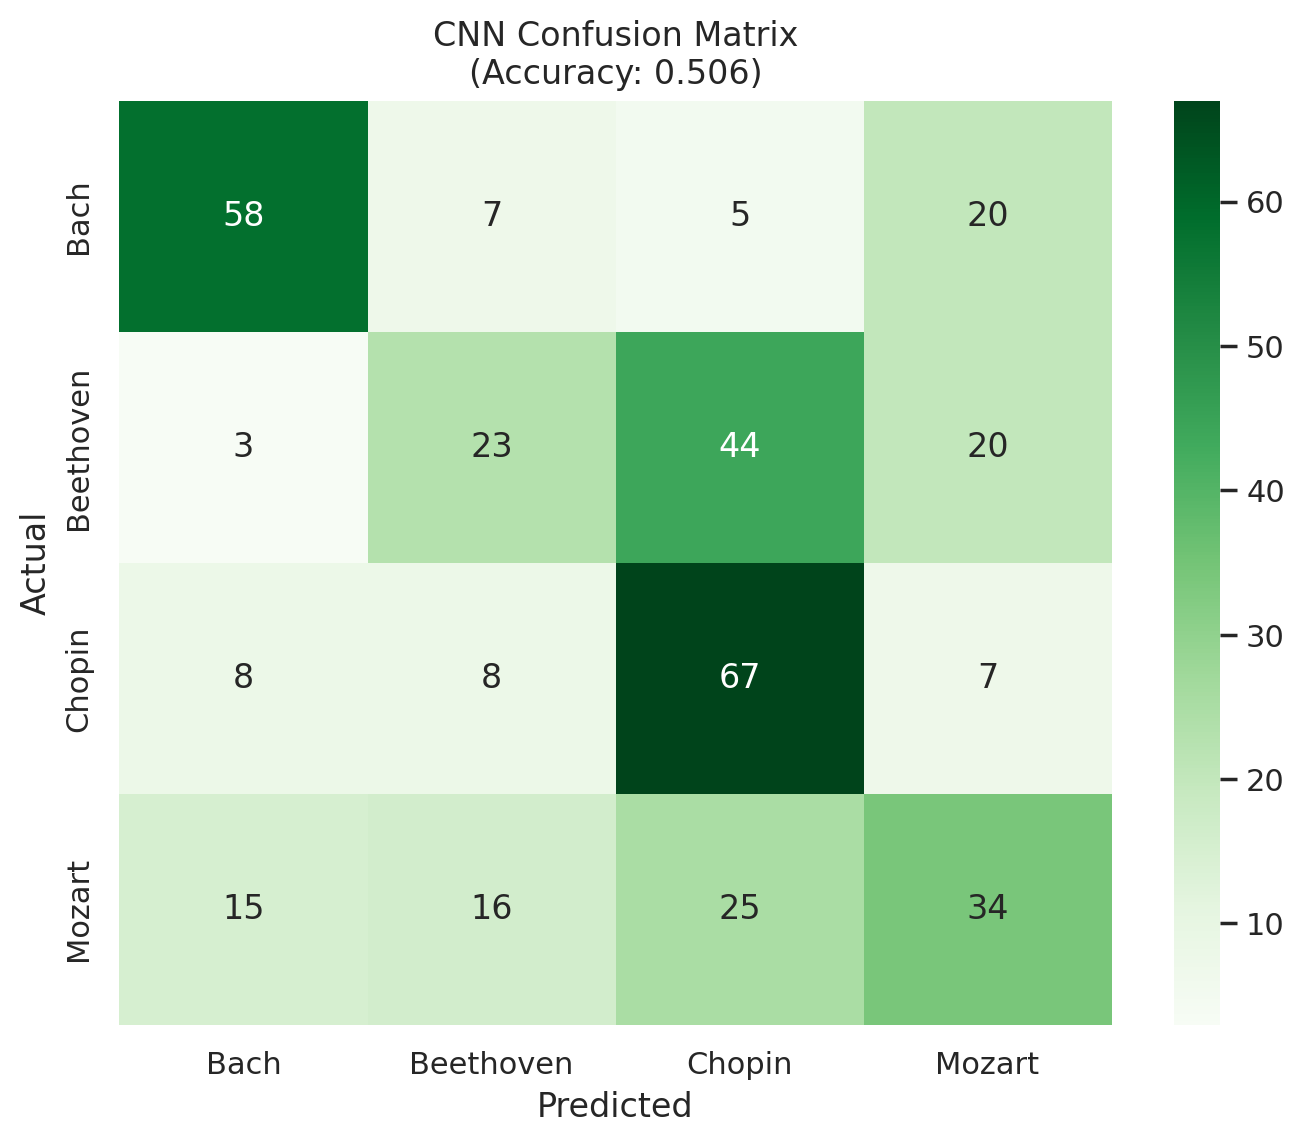

In [ ]:
# =============================================================================
# CNN: MODEL EVALUATION
# =============================================================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
y_cnn_pred_probs = cnn_model.predict(X_cnn_test)
y_cnn_pred = np.argmax(y_cnn_pred_probs, axis=1)

# Overall accuracy
cnn_test_accuracy = accuracy_score(y_cnn_test, y_cnn_pred)
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}\n")

# Precision, Recall, F1 per composer
print("CNN Classification Report:")
print(classification_report(y_cnn_test, y_cnn_pred, target_names=composers_list))

# Confusion matrix
print("\nCNN Confusion Matrix:")
cm_cnn = confusion_matrix(y_cnn_test, y_cnn_pred)
print(cm_cnn)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=composers_list, yticklabels=composers_list)
plt.title(f'CNN Confusion Matrix\n(Accuracy: {cnn_test_accuracy:.3f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

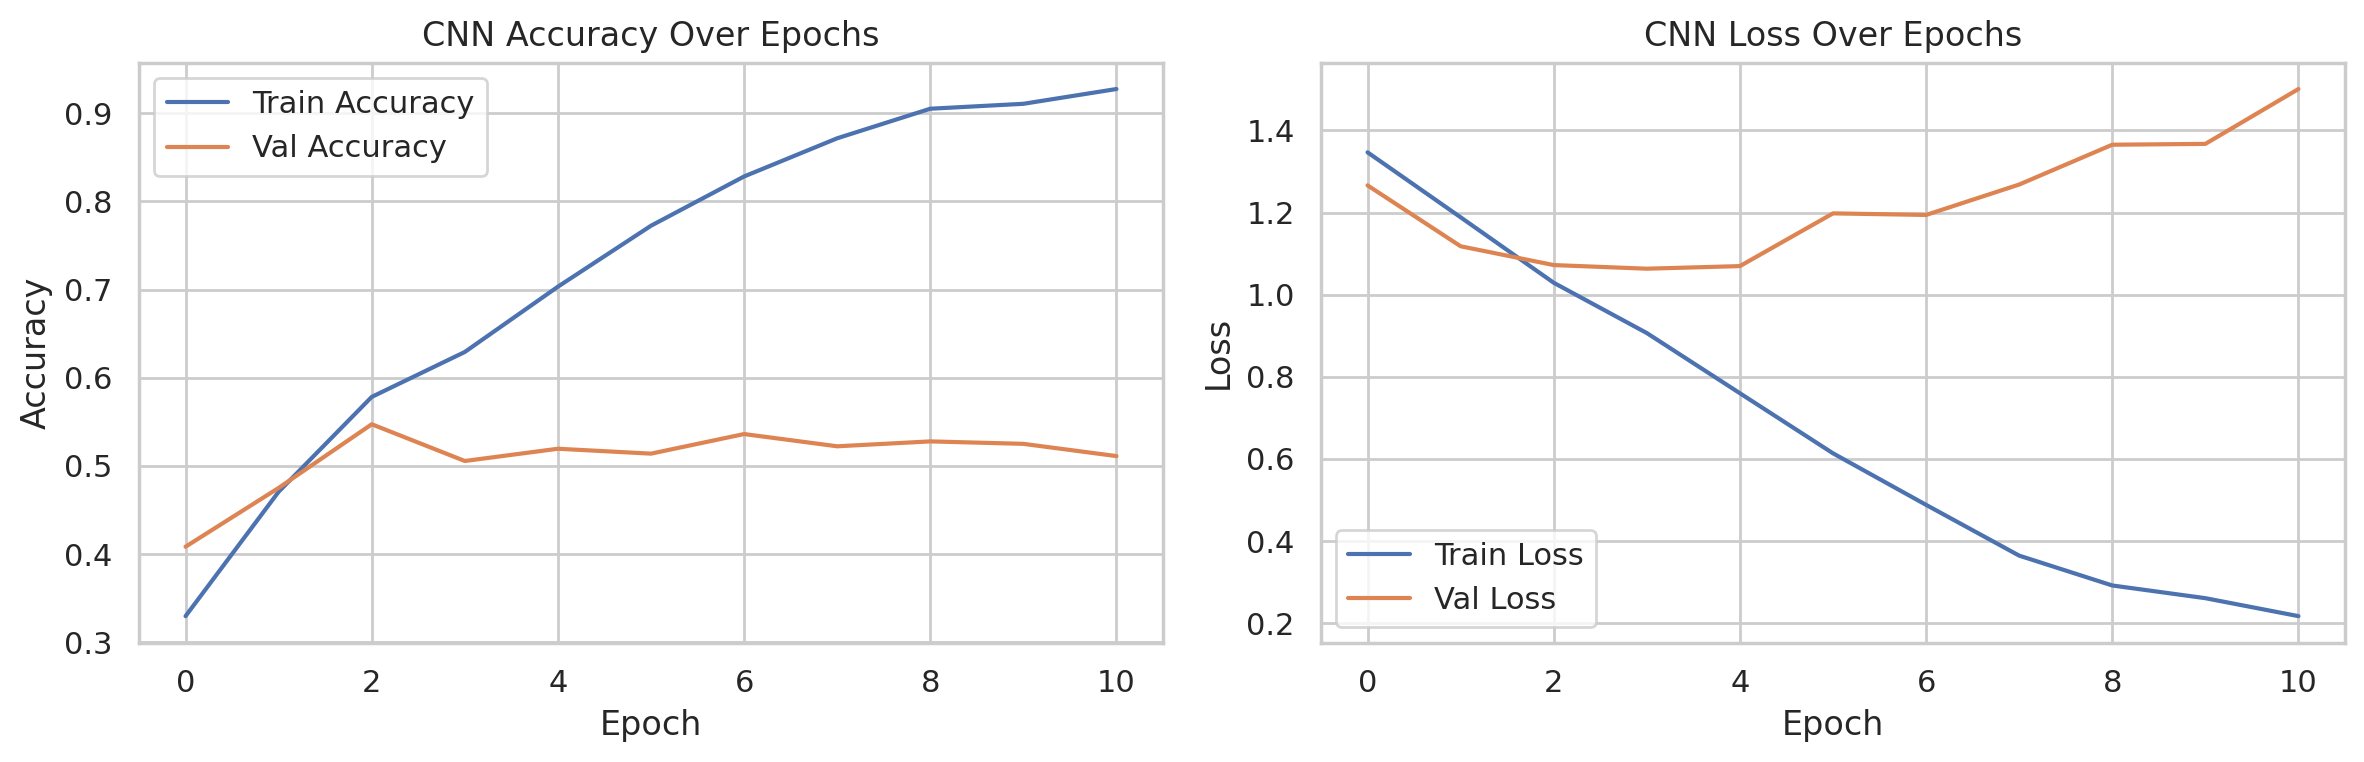

In [ ]:
# =============================================================================
# CNN: TRAINING HISTORY
# =============================================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Accuracy Over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Loss Over Epochs')

plt.tight_layout()
plt.show()

###**Observation on the CNN Model:**

The CNN model performed moderately with a 50.56% accuracy on the 4-composer classification task (Bach, Beethoven, Chopin, Mozart). The confusion matrix shows the model heavily over-predicts. Chopin — 25 of 90 actual Mozart pieces and 44 of 90 actual Beethoven pieces were misclassified as Chopin, while Mozart recall collapsed to essentially 0.38 (34 out of 90 correct). Bach and Chopin were reasonably well distinguished from each other, but Beethoven and Mozart were largely absorbed into the other's class or Chopin's.

The CNN training curves show validation accuracy plateauing a little over 0.5 after 2 epochs with a validation loss gradually increasing after 4 epochs, while training accuracy climbed more steadily to over 0.9 — a sign of instability/overfitting rather than clean convergence.

OVERALL ACCURACY COMPARISON
LSTM Test Accuracy:  0.7914 (79.14%)
CNN Test Accuracy:   0.5056 (50.56%)
Difference:          -0.2859 (-28.59%)
LSTM outperforms CNN by 28.59%

PER-COMPOSER METRICS (Precision, Recall, F1-Score)
 Composer  LSTM Precision  CNN Precision  LSTM Recall  CNN Recall  LSTM F1   CNN F1
     Bach        0.710191       0.690476     0.835206    0.644444 0.767642 0.666667
Beethoven        0.819095       0.425926     0.679167    0.255556 0.742597 0.319444
   Chopin        0.818951       0.475177     0.937984    0.744444 0.874435 0.580087
   Mozart        0.849148       0.419753     0.700803    0.377778 0.767877 0.397661



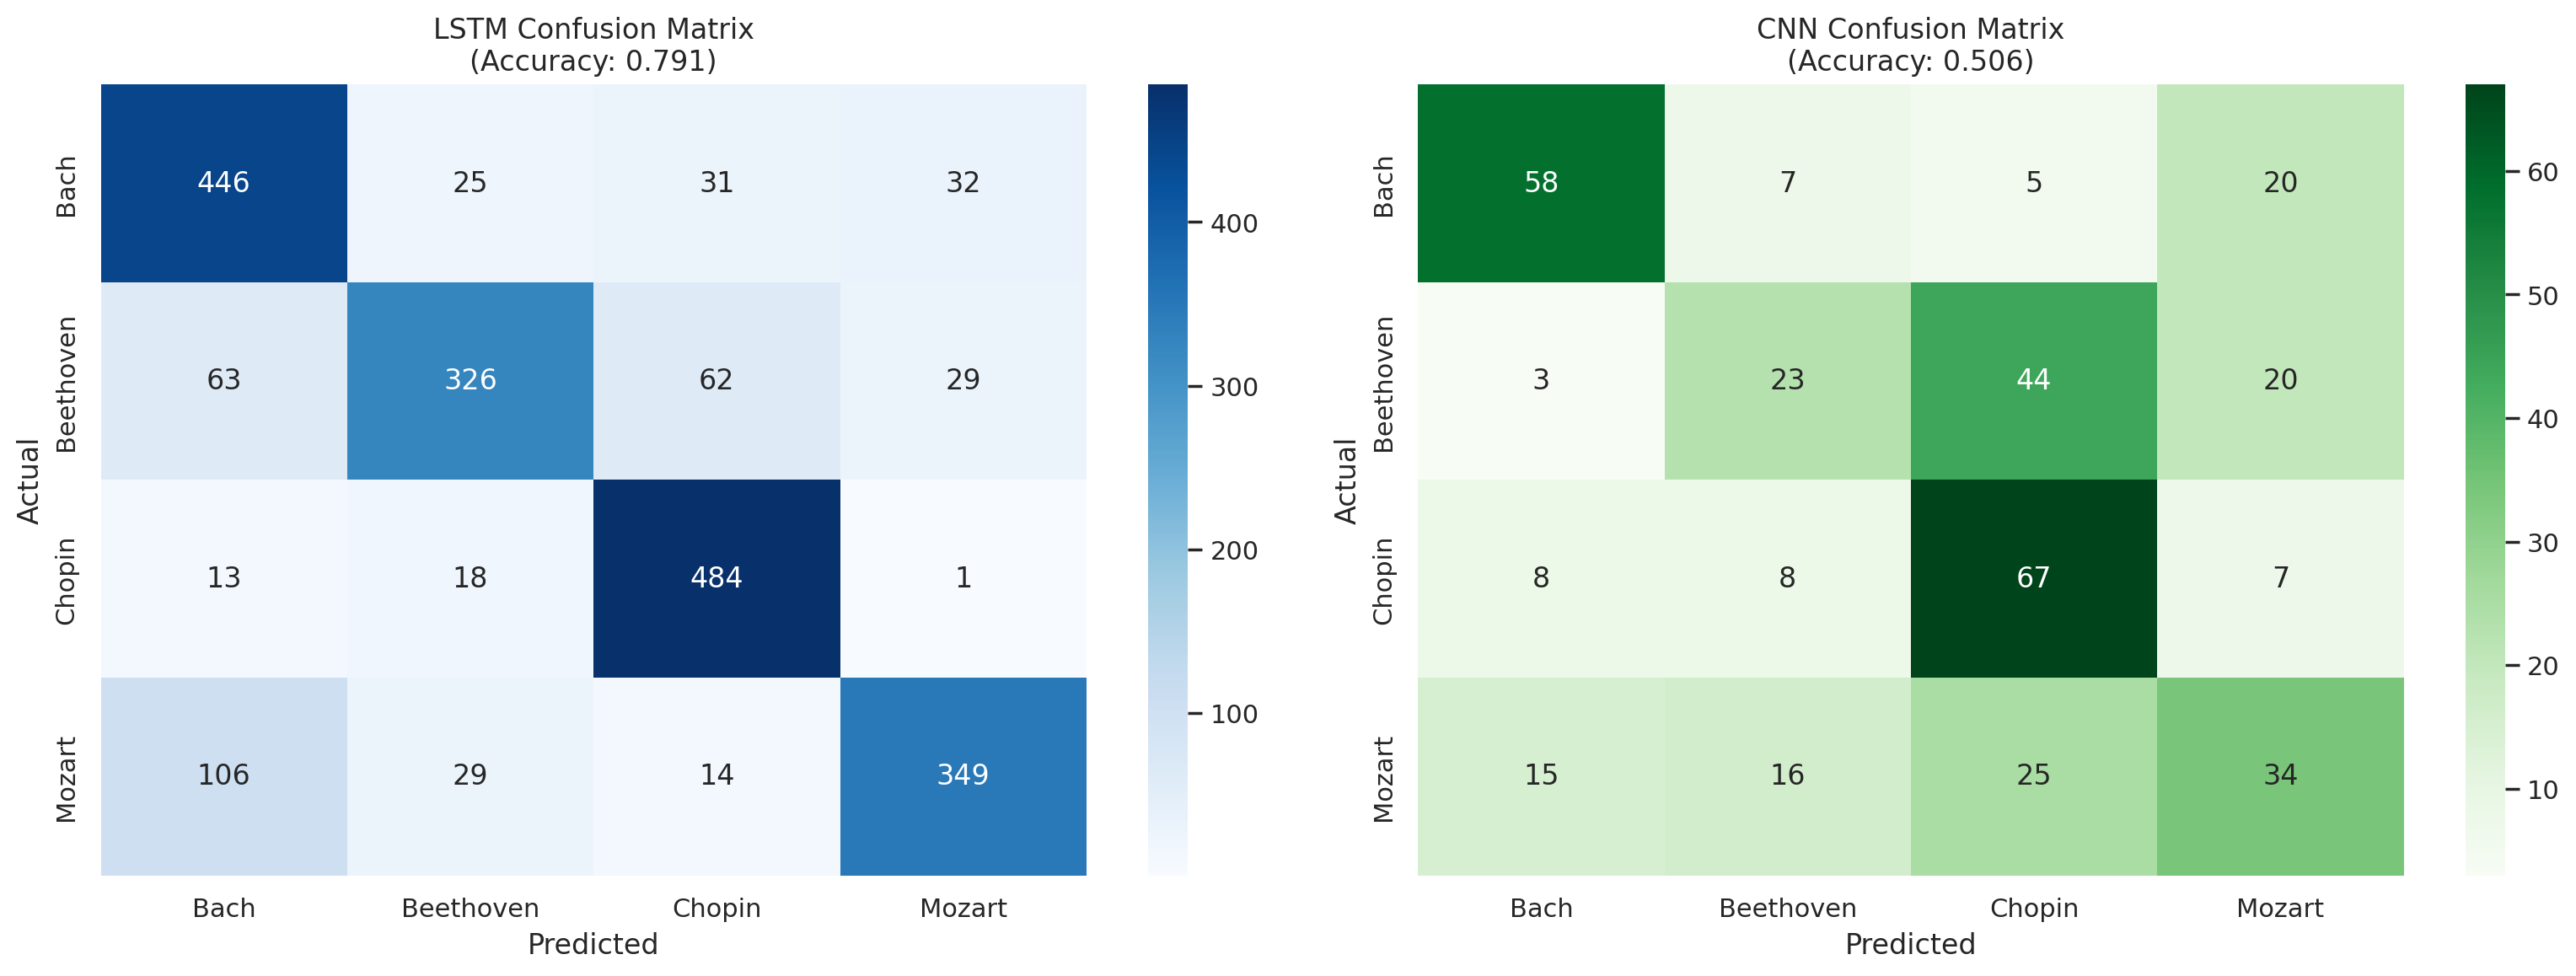

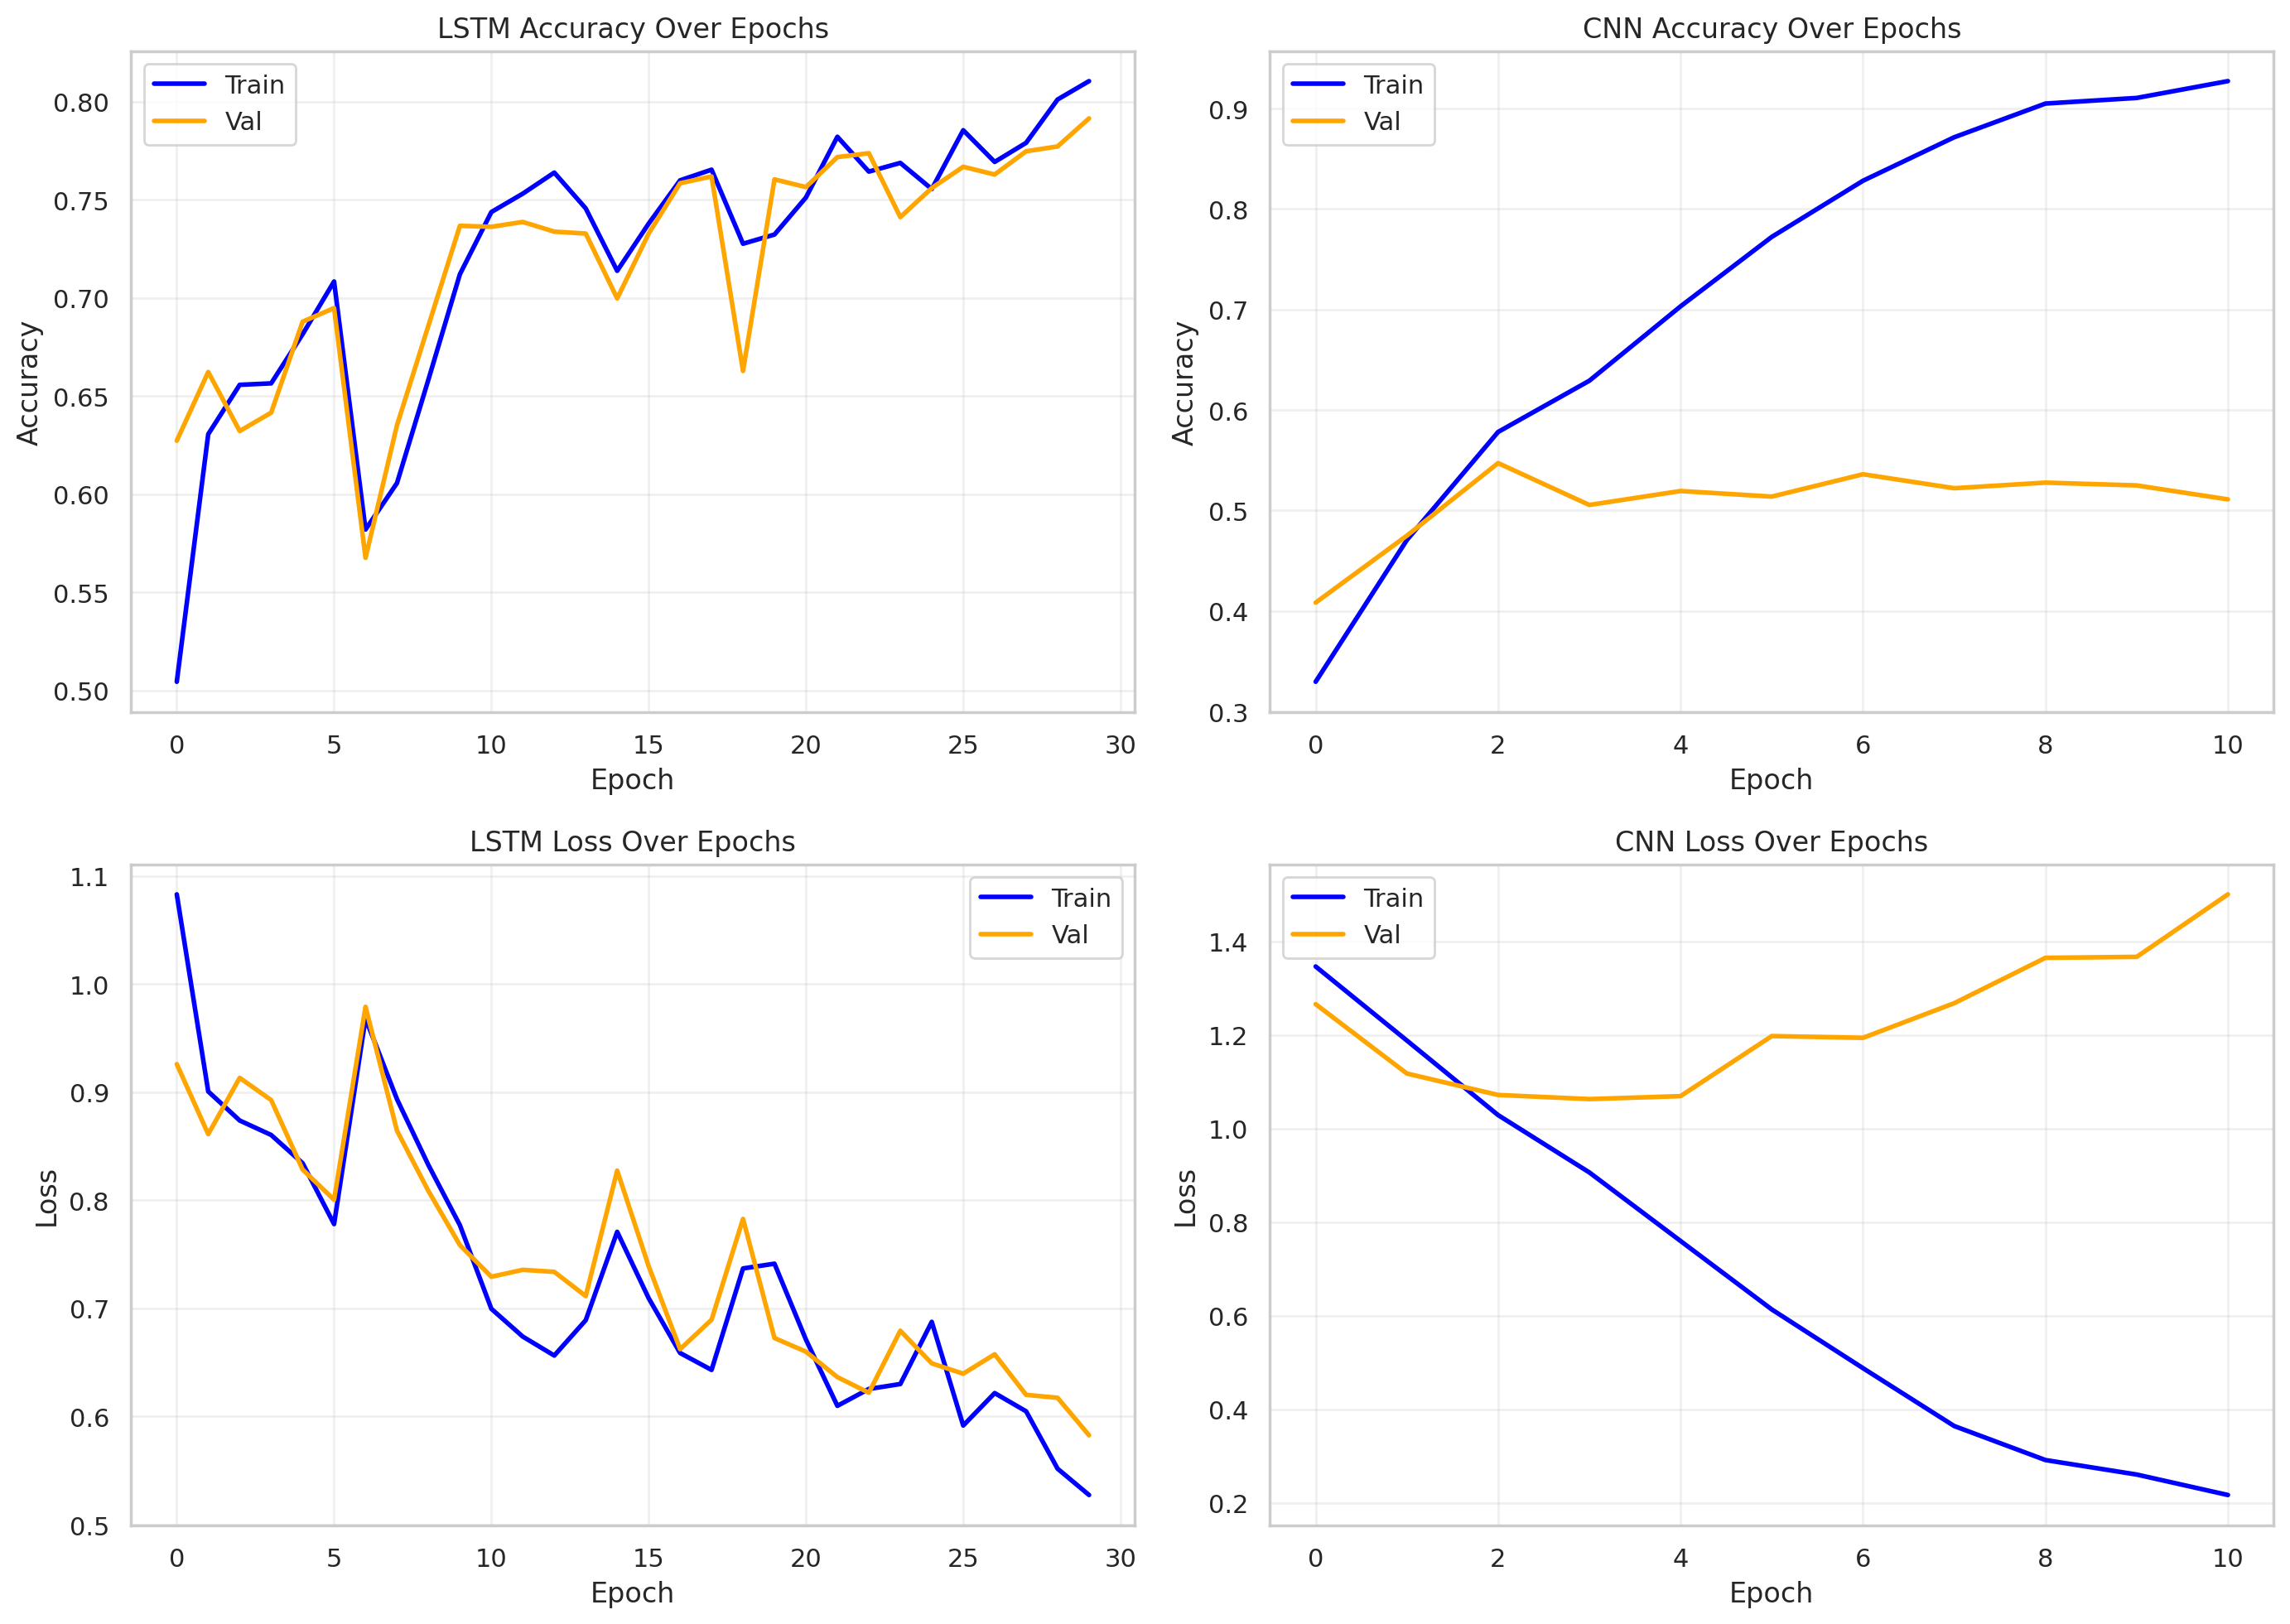

SUMMARY INSIGHTS
1. Overall Winner: LSTM by 28.59% accuracy

2. Mozart Classification:
   LSTM: 70.1% recall
   CNN:  37.8% recall

3. Model Characteristics:
   LSTM: Learns sequential patterns in note/chord progressions
   CNN:  Learns spatial patterns in piano roll (harmony, texture)


In [ ]:
# =============================================================================
# LSTM vs CNN: COMPARISON
# =============================================================================

from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

print("=" * 60)
print("OVERALL ACCURACY COMPARISON")
print("=" * 60)
print(f"LSTM Test Accuracy:  {lstm_test_accuracy:.4f} ({lstm_test_accuracy*100:.2f}%)")
print(f"CNN Test Accuracy:   {cnn_test_accuracy:.4f} ({cnn_test_accuracy*100:.2f}%)")
print(f"Difference:          {(cnn_test_accuracy - lstm_test_accuracy):.4f} ({(cnn_test_accuracy - lstm_test_accuracy)*100:.2f}%)")
if cnn_test_accuracy > lstm_test_accuracy:
    print(f"CNN outperforms LSTM by {(cnn_test_accuracy - lstm_test_accuracy)*100:.2f}%")
else:
    print(f"LSTM outperforms CNN by {(lstm_test_accuracy - cnn_test_accuracy)*100:.2f}%")
print()

# Per-Composer Metrics Comparison
print("=" * 60)
print("PER-COMPOSER METRICS (Precision, Recall, F1-Score)")
print("=" * 60)

# Get metrics for LSTM
lstm_precision, lstm_recall, lstm_f1, _ = precision_recall_fscore_support(
    lstm_y_test, lstm_y_pred, labels=range(num_classes), average=None
)

# Get metrics for CNN
cnn_precision, cnn_recall, cnn_f1, _ = precision_recall_fscore_support(
    y_cnn_test, y_cnn_pred, labels=range(num_classes), average=None
)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Composer': composers_list,
    'LSTM Precision': lstm_precision,
    'CNN Precision': cnn_precision,
    'LSTM Recall': lstm_recall,
    'CNN Recall': cnn_recall,
    'LSTM F1': lstm_f1,
    'CNN F1': cnn_f1
})

print(comparison_df.to_string(index=False))
print()

# Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LSTM Confusion Matrix
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=composers_list, yticklabels=composers_list, ax=axes[0])
axes[0].set_title(f'LSTM Confusion Matrix\n(Accuracy: {lstm_test_accuracy:.3f})')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# CNN Confusion Matrix
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=composers_list, yticklabels=composers_list, ax=axes[1])
axes[1].set_title(f'CNN Confusion Matrix\n(Accuracy: {cnn_test_accuracy:.3f})')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Training Curves Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LSTM Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', color='blue', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Val', color='orange', linewidth=2)
axes[0, 0].set_title('LSTM Accuracy Over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# CNN Accuracy
axes[0, 1].plot(history_cnn.history['accuracy'], label='Train', color='blue', linewidth=2)
axes[0, 1].plot(history_cnn.history['val_accuracy'], label='Val', color='orange', linewidth=2)
axes[0, 1].set_title('CNN Accuracy Over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# LSTM Loss
axes[1, 0].plot(history.history['loss'], label='Train', color='blue', linewidth=2)
axes[1, 0].plot(history.history['val_loss'], label='Val', color='orange', linewidth=2)
axes[1, 0].set_title('LSTM Loss Over Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# CNN Loss
axes[1, 1].plot(history_cnn.history['loss'], label='Train', color='blue', linewidth=2)
axes[1, 1].plot(history_cnn.history['val_loss'], label='Val', color='orange', linewidth=2)
axes[1, 1].set_title('CNN Loss Over Epochs')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary Insights
print("=" * 60)
print("SUMMARY INSIGHTS")
print("=" * 60)

if cnn_test_accuracy > lstm_test_accuracy:
    winner = "CNN"
    margin = (cnn_test_accuracy - lstm_test_accuracy) * 100
else:
    winner = "LSTM"
    margin = (lstm_test_accuracy - cnn_test_accuracy) * 100

print(f"1. Overall Winner: {winner} by {margin:.2f}% accuracy")
print()

# Mozart-specific analysis
mozart_idx = composers_list.index('Mozart')
print(f"2. Mozart Classification:")
print(f"   LSTM: {lstm_recall[mozart_idx]*100:.1f}% recall")
print(f"   CNN:  {cnn_recall[mozart_idx]*100:.1f}% recall")
print()

print(f"3. Model Characteristics:")
print(f"   LSTM: Learns sequential patterns in note/chord progressions")
print(f"   CNN:  Learns spatial patterns in piano roll (harmony, texture)")
print("=" * 60)

###**Observation on LTSM vs CNN:**

The LTSM model outperforms the CNN model by 28.59% on accuracy (79% vs 51%). Recall dropped sharply for Beethoven (-42%) and especially Mozart (-32%), which is the key weakness of the CNN model. For Bach and Chopin, the CNN model was inferior with a recall that was nearly 20 points lower than the LSTM model. The CNN model essentially fails to detect the composers. The nature of the LSTM model to learn sequential patterns in note and chord progressions allows it to produce suprior results.

ALL IN ONE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00


Downloading...
From (original): https://drive.google.com/uc?id=1QJPbVi6q2QPIiD47ZBf9tDxhM4ON-7mj
From (redirected): https://drive.google.com/uc?id=1QJPbVi6q2QPIiD47ZBf9tDxhM4ON-7mj&confirm=t&uuid=230b6dc5-e46f-4fbf-bafe-068beed4917a
To: /content/data/midi_data/midi-classic-music.zip
100%|██████████| 36.4M/36.4M [00:01<00:00, 23.3MB/s]



Extracting ./data/midi_data/midi-classic-music.zip...
Extraction complete! Files are located in: ./data/midi_data
['Resch', 'Kuhlau Sonatina op55 n3 1mov.mid', 'Vivaldi', 'Schoenberg', 'Haendel', 'Friedman', 'Diabelli Sonatina op151 n3 2mov.mid', 'Shostakovich', 'Scarlatti', 'Bartelet', 'Liszt Paganini Etude n1.mid', 'Ivanovici', 'Burgmuller', 'Heller', 'Buxethude Buxwv156 Toccata.mid', 'Coleridge-Taylor', 'Lange', 'Buxethude Buxwv160 Ciacona.mid', 'Finck', 'Haydn', 'Rothchild Oboe Concerto Rmw09 1mov.mid', 'Diabelli Sonatina op151 n2 2mov.mid', 'Bartok', 'Varios - Título desconocido', 'Sarasate', 'Beethoven', 'Debussy Suite Bergamasque 4mov.mid', 'Hemery', 'Alkan', 'Chaminade', 'Grainger', 'Peterson-Berger', 'Durand, E', 'Wolf', 'C.P.E.Bach Solfeggieto.mid', 'Satie', 'Dvorak Trio op26.mid', 'Lecuona', 'Diabelli Sonatina op151 n4 2mov.mid', 'Sibelius Kuolema Vals op44.mid', 'Dussek', 'Coates', 'Tchaikovsky Lake Of The Swans Act 2 11mov.mid', 'Katzwarra', 'Schumann', 'Saint-Saens', 'W

Validating MIDI files:   0%|          | 0/1630 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Validating MIDI files: 100%|██████████| 1630/1630 [02:46<00:00,  9.79it/s]



Cleaning Summary
Valid Files: 1626
Corrupt/Empty Files Removed: 4
Example error: ('./data/midi_data/Buxethude Buxwv161 Passcaglia.mid', 'list index out of range')
Original Clean File Counts
Beethoven: 132
Bach: 122
Mozart: 90
Chopin: 136

Balancing dataset to 90 files per composer

Balanced Dataset Summary
Total Balanced Files: 360


Extracting EDA Features:   2%|▎         | 9/360 [00:01<00:55,  6.30it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Extracting EDA Features: 100%|██████████| 360/360 [00:44<00:00,  8.01it/s]


,Composer,Length_Seconds,Total_Notes,Notes_Per_Second,Estimated_BPM,Average_Pitch,Pitch_Range
0,Bach,618.158060,4421,7.151893,160.827960,64.347659,44
1,Bach,745.165200,4493,6.029535,246.250401,63.583352,48
2,Bach,515.662760,3367,6.529461,218.689311,64.756460,46
3,Bach,857.375929,20062,23.399304,260.798348,65.825740,72
4,Bach,682.367570,5930,8.690331,164.093996,67.226644,48


/tmp/ipykernel_510/3081732147.py:245: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x="Composer", palette="viridis")
/tmp/ipykernel_510/3081732147.py:250: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="Composer", y="Notes_Per_Second", palette="viridis")
/tmp/ipykernel_510/3081732147.py:256: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_eda, x="Composer", y="Length_Seconds", palette="viridis")


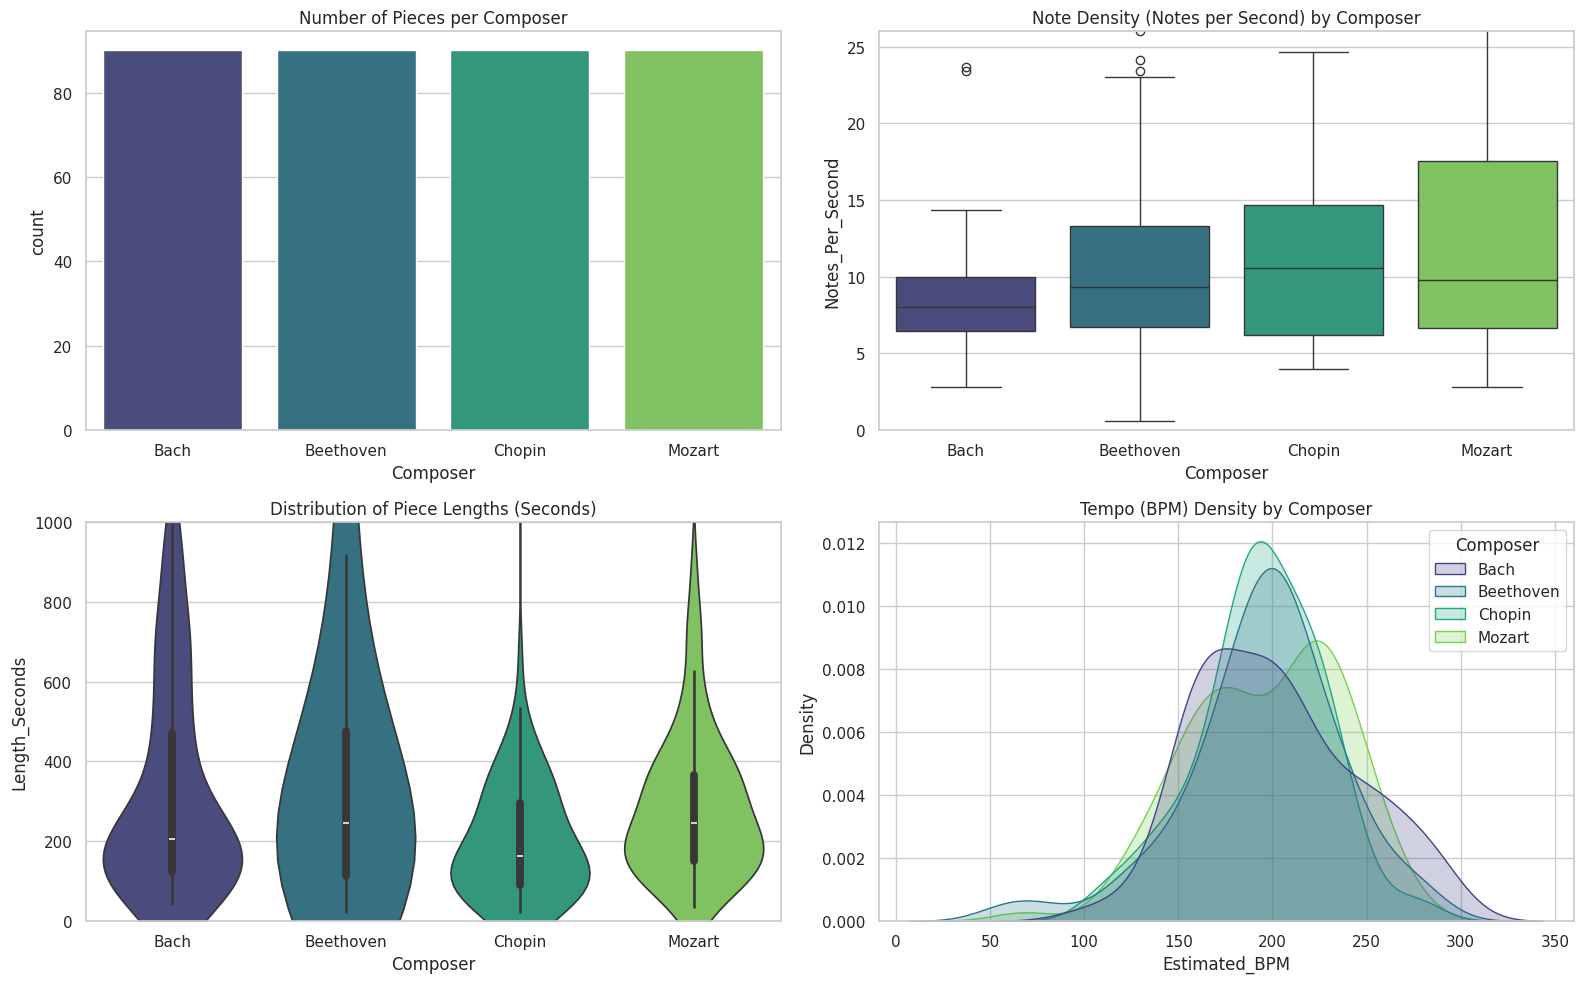

Extracting sequences with time stretching:   0%|          | 0/360 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
Extracting sequences with time stretching:  11%|█▏        | 41/360 [04:48<17:34,  3.31s/it]/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Preludiul nr.3 \xeen re minor, BWV 935'>; getting generic Instrument
  warnings.warn(
Extracting sequences with time stretching:  26%|██▋       | 95/360 [09:17<15:52,  3.59s/it]/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Concerto pour violon et orchestre en R\xe9 majeur'>; getting generic Instrument


Successfully extracted sequences from 1080 augmented versions
  (Original files: 360), Augmentation factor: 3x)
Failed to extract: 0 files
Vocabulary size: 902 unique note/chord tokens

Example encoded sequence (first 20 tokens) from a Bach piece:
[846, 866, 873, 839, 892, 839, 873, 880, 893, 873, 839, 873, 893, 827, 840, 893, 847, 893, 827, 880]

Sequence length stats:
Min: 29, Max: 5210, Mean: 842
Composer label mapping: {'Bach': 0, 'Beethoven': 1, 'Chopin': 2, 'Mozart': 3}
Total training windows generated: 10140
X shape: (10140, 100), y shape: (10140,)
  Bach: 2670 windows
  Beethoven: 2400 windows
  Chopin: 2580 windows
  Mozart: 2490 windows
Train shape: (8112, 100), Test shape: (2028, 100)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 59s 404ms/step - accuracy: 0.4985 - loss: 1.0972 - val_accuracy: 0.5858 - val_loss: 0.9720
Epoch 2/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 49s 386ms/step - accuracy: 0.6203 - loss: 0.9210 - val_accuracy: 0.6706 - val_loss: 0.8585
Epoch 3/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 82s 387ms/step - accuracy: 0.6674 - loss: 0.8671 - val_accuracy: 0.6667 - val_loss: 0.8477
Epoch 4/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 49s 387ms/step - accuracy: 0.6252 - loss: 0.9303 - val_accuracy: 0.6381 - val_loss: 0.8987
Epoch 5/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 83s 397ms/step - accuracy: 0.6786 - loss: 0.8398 - val_accuracy: 0.6943 - val_loss: 0.8134
Epoch 6/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 50s 391ms/step - accuracy: 0.7143 - loss: 0.7772 - val_accuracy: 0.7150 - val_loss: 0.7890
Epoch 7/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 47s 373ms/step - accuracy: 0.6953 - loss: 0.8044 - val_accuracy: 0.7140 - val_loss: 0.8165
Epoch 8/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 49s 386ms/step - accuracy: 0.7345 - loss: 0

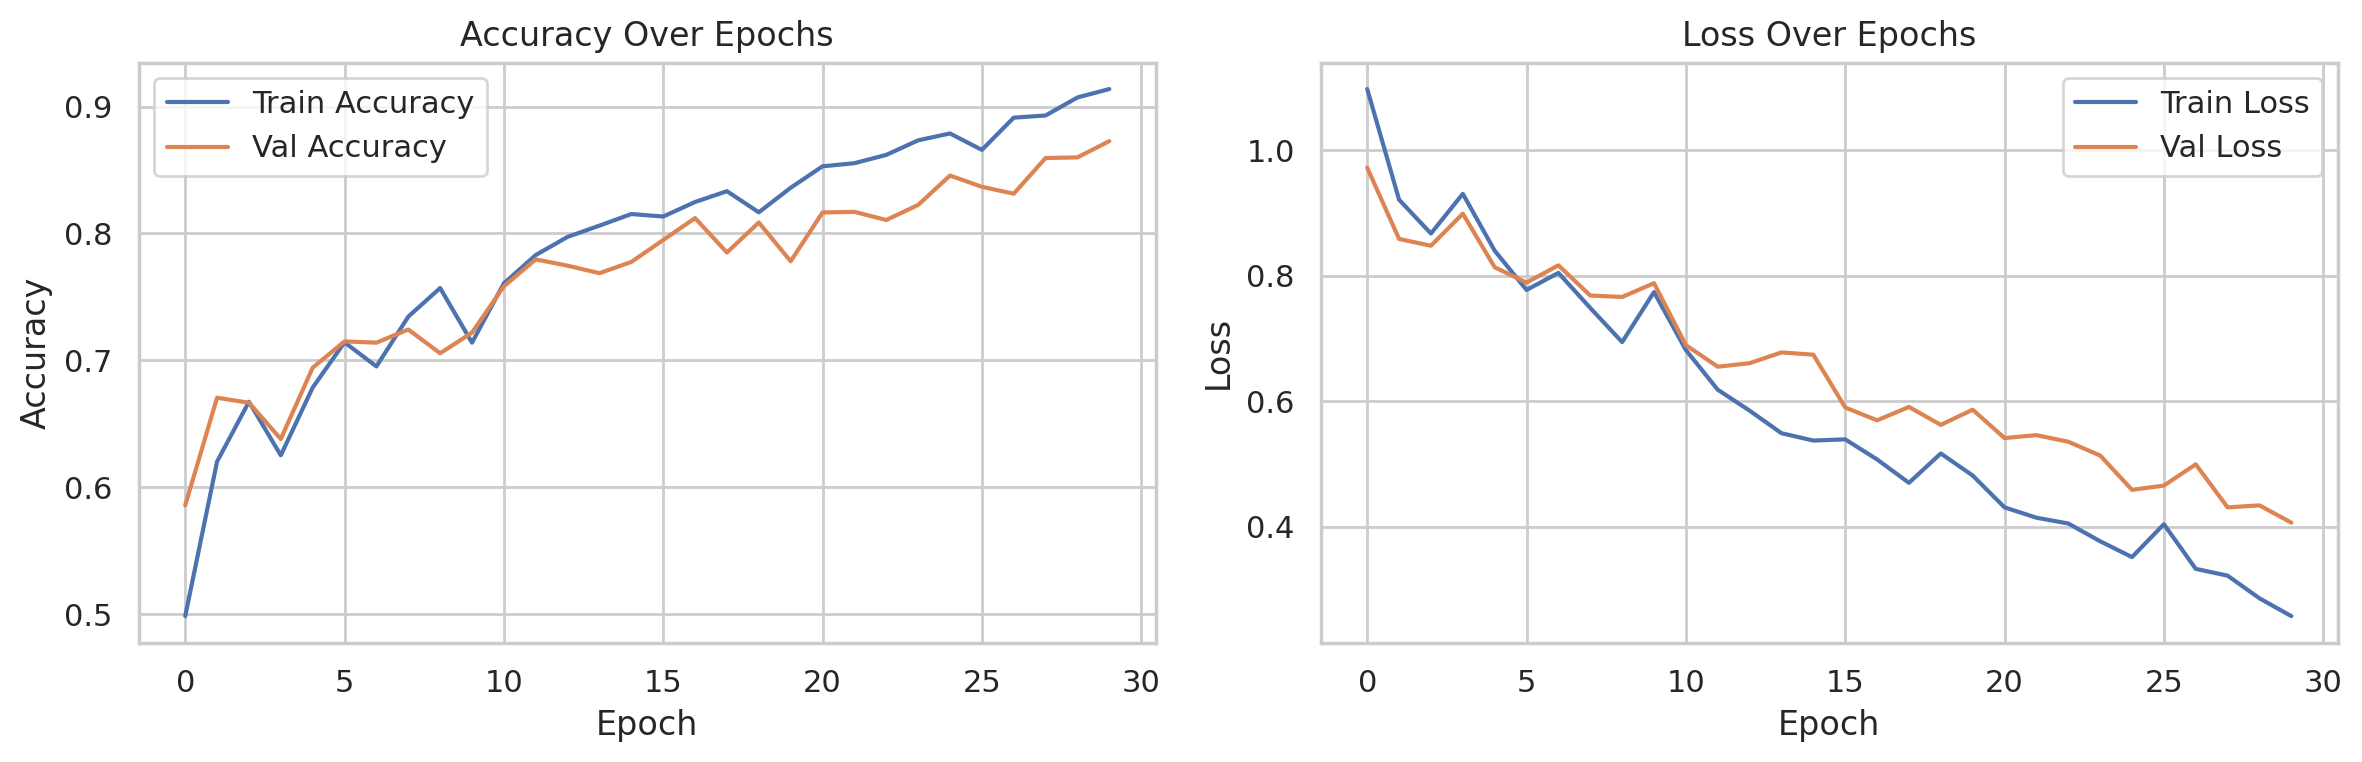

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step
Test Accuracy: 0.8728

Classification Report:
              precision    recall  f1-score   support

        Bach       0.84      0.87      0.85       534
   Beethoven       0.83      0.87      0.85       480
      Chopin       0.93      0.92      0.92       516
      Mozart       0.90      0.83      0.86       498

    accuracy                           0.87      2028
   macro avg       0.87      0.87      0.87      2028
weighted avg       0.87      0.87      0.87      2028


Confusion Matrix:
[[465  33  13  23]
 [ 28 418  18  16]
 [ 18  17 473   8]
 [ 45  33   6 414]]


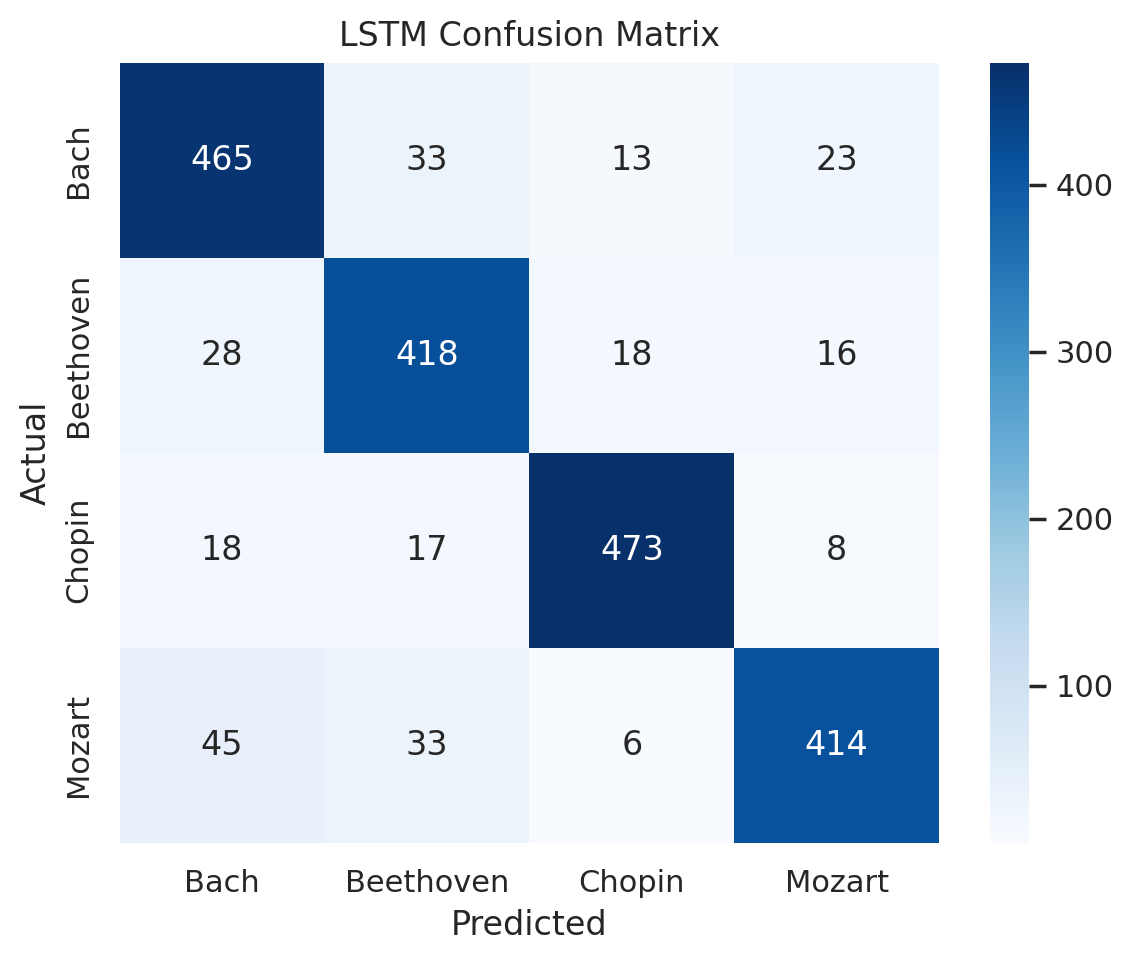

Train files: 288, Test files: 72
Piano roll conversion function ready.
Piano roll dimensions: (time_steps, 88 pitches)
Pitch range: 21 (A0) to 108 (C8)
Time resolution: 10 fps (0.1 second per frame)


Extracting CNN piano rolls:   2%|▎         | 9/360 [00:01<00:53,  6.56it/s]/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Extracting CNN piano rolls: 100%|██████████| 360/360 [00:42<00:00,  8.50it/s]
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Successfully extracted 1792 CNN piano roll segments
  (Original files: 360)
  (Segments per file: 5)
Skipped silent segments: 50 (note density < 1%)
Failed to extract: 0 files

Each segment shape: (100 frames, 88 pitches)
Segment duration: 10 seconds at 10 fps
Values normalized to [0, 1] range
Composers: ['Bach', 'Beethoven', 'Chopin', 'Mozart']
num_classes = 4
Using saved train/test split: 288 train files, 72 test files

CNN Training Data:
X_cnn_train shape: (1432, 100, 88, 1)
X_cnn_test shape: (360, 100, 88, 1)

Train set class distribution:
  Bach: 360 segments
  Beethoven: 357 segments
  Chopin: 360 segments
  Mozart: 355 segments

Test set class distribution:
  Bach: 90 segments
  Beethoven: 90 segments
  Chopin: 90 segments
  Mozart: 90 segments


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 88, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 44, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 44, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 44, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 25, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 17600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,126,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,131,524 (4.32 MB)

 Trainable params: 1,131,524 (4.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 273ms/step - accuracy: 0.3443 - loss: 1.3402 - val_accuracy: 0.4750 - val_loss: 1.2534 - learning_rate: 0.0010
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 262ms/step - accuracy: 0.4637 - loss: 1.1969 - val_accuracy: 0.4389 - val_loss: 1.1750 - learning_rate: 0.0010
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 248ms/step - accuracy: 0.5726 - loss: 1.0574 - val_accuracy: 0.5333 - val_loss: 1.0817 - learning_rate: 0.0010
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 255ms/step - accuracy: 0.6411 - loss: 0.9133 - val_accuracy: 0.5361 - val_loss: 1.1147 - learning_rate: 0.0010
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - accuracy: 0.7039 - loss: 0.7689 - val_accuracy: 0.5028 - val_loss: 1.0941 - learning_rate: 0.0010
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7674 - loss: 0.6450
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - accuracy: 0.7730 - loss: 0.61

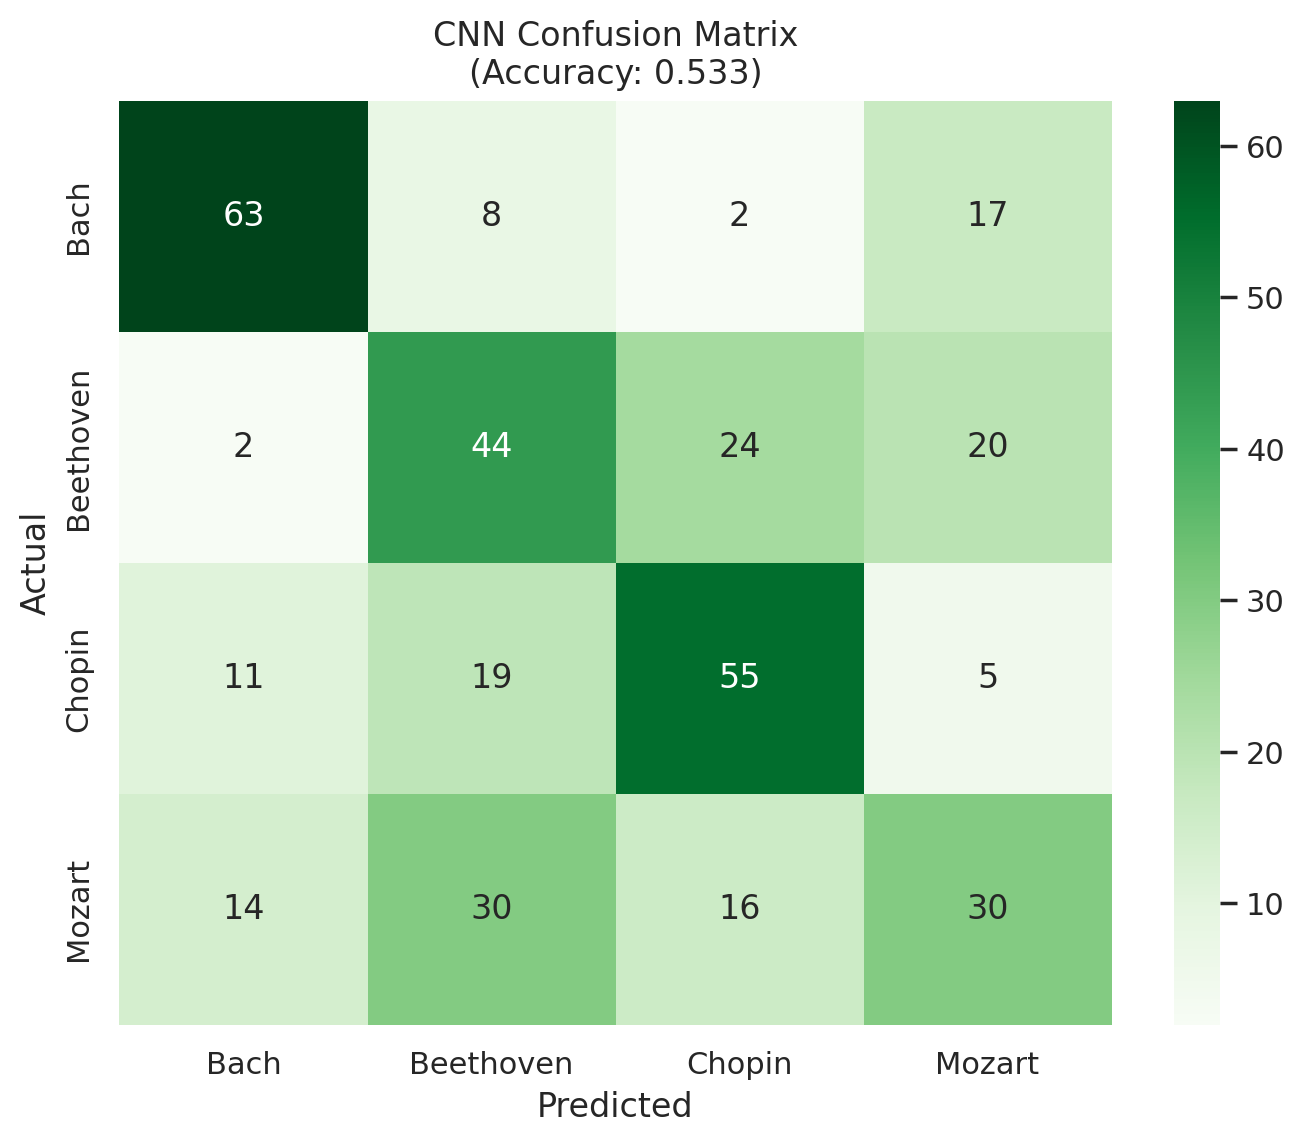

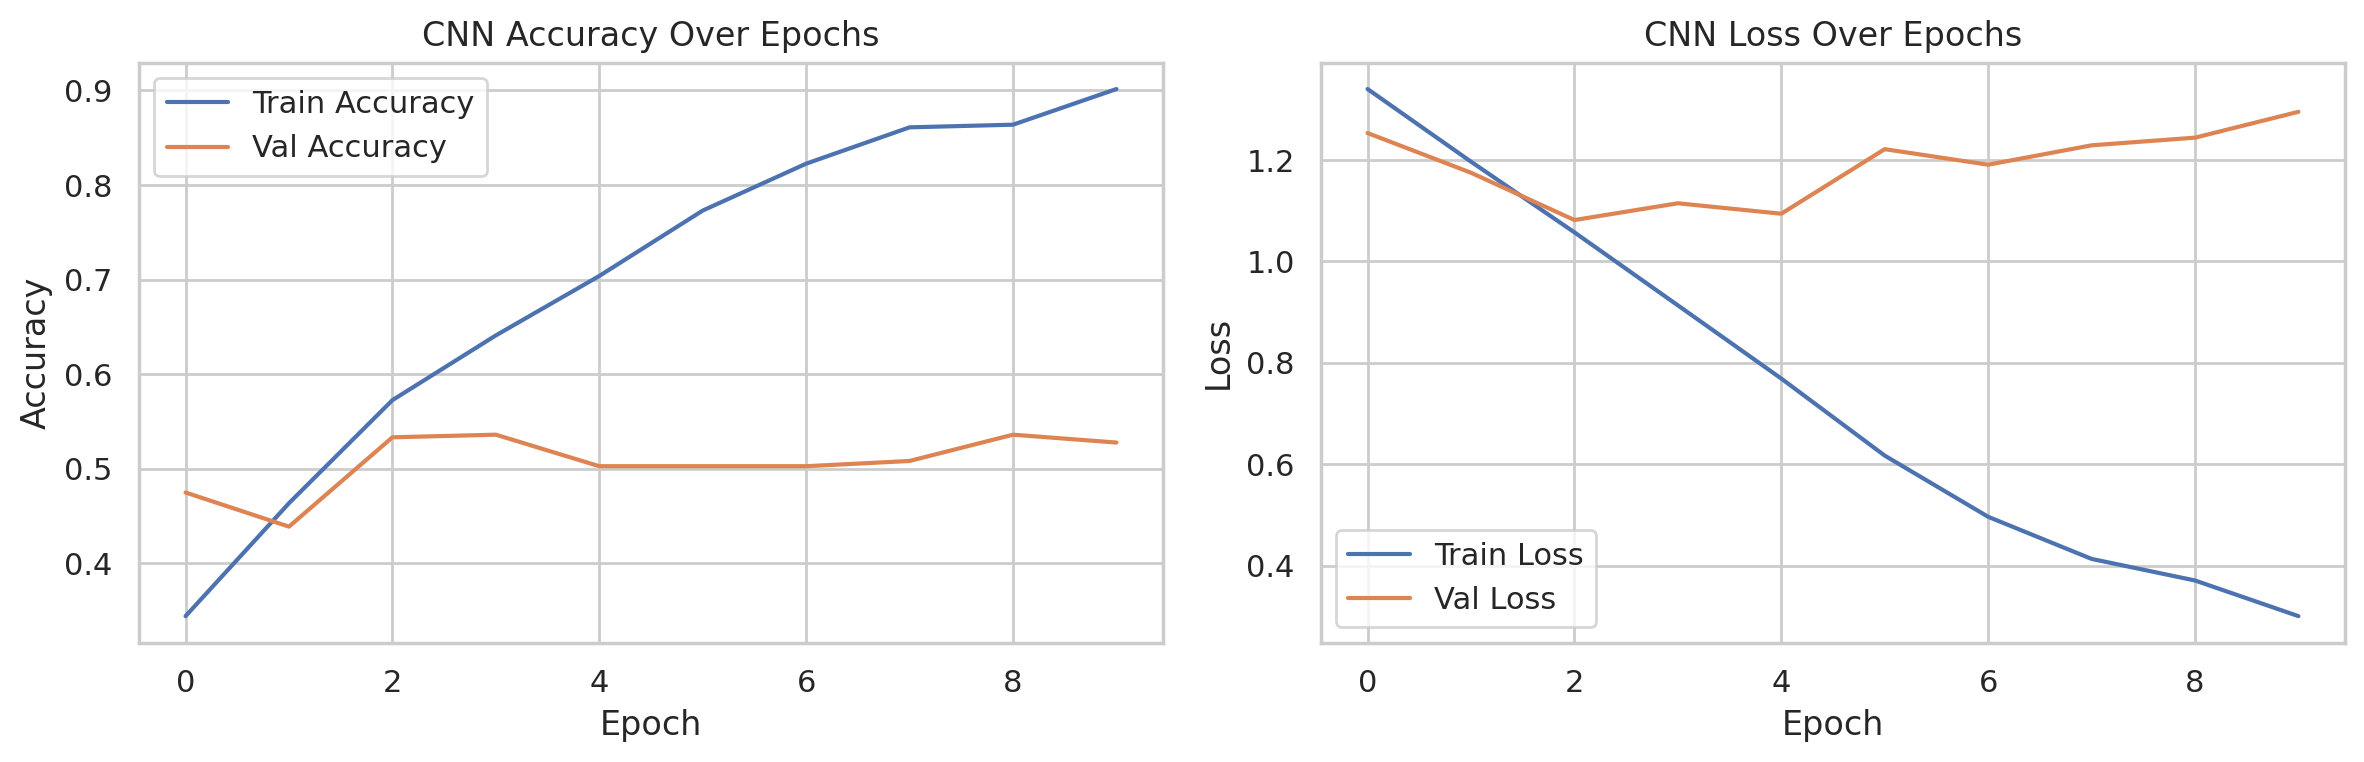

OVERALL ACCURACY COMPARISON
LSTM Test Accuracy:  0.8728 (87.28%)
CNN Test Accuracy:   0.5333 (53.33%)
Difference:          -0.3394 (-33.94%)
LSTM outperforms CNN by 33.94%

PER-COMPOSER METRICS (Precision, Recall, F1-Score)
 Composer  LSTM Precision  CNN Precision  LSTM Recall  CNN Recall  LSTM F1   CNN F1
     Bach        0.836331       0.700000     0.870787    0.700000 0.853211 0.700000
Beethoven        0.834331       0.435644     0.870833    0.488889 0.852192 0.460733
   Chopin        0.927451       0.567010     0.916667    0.611111 0.922027 0.588235
   Mozart        0.898048       0.416667     0.831325    0.333333 0.863399 0.370370



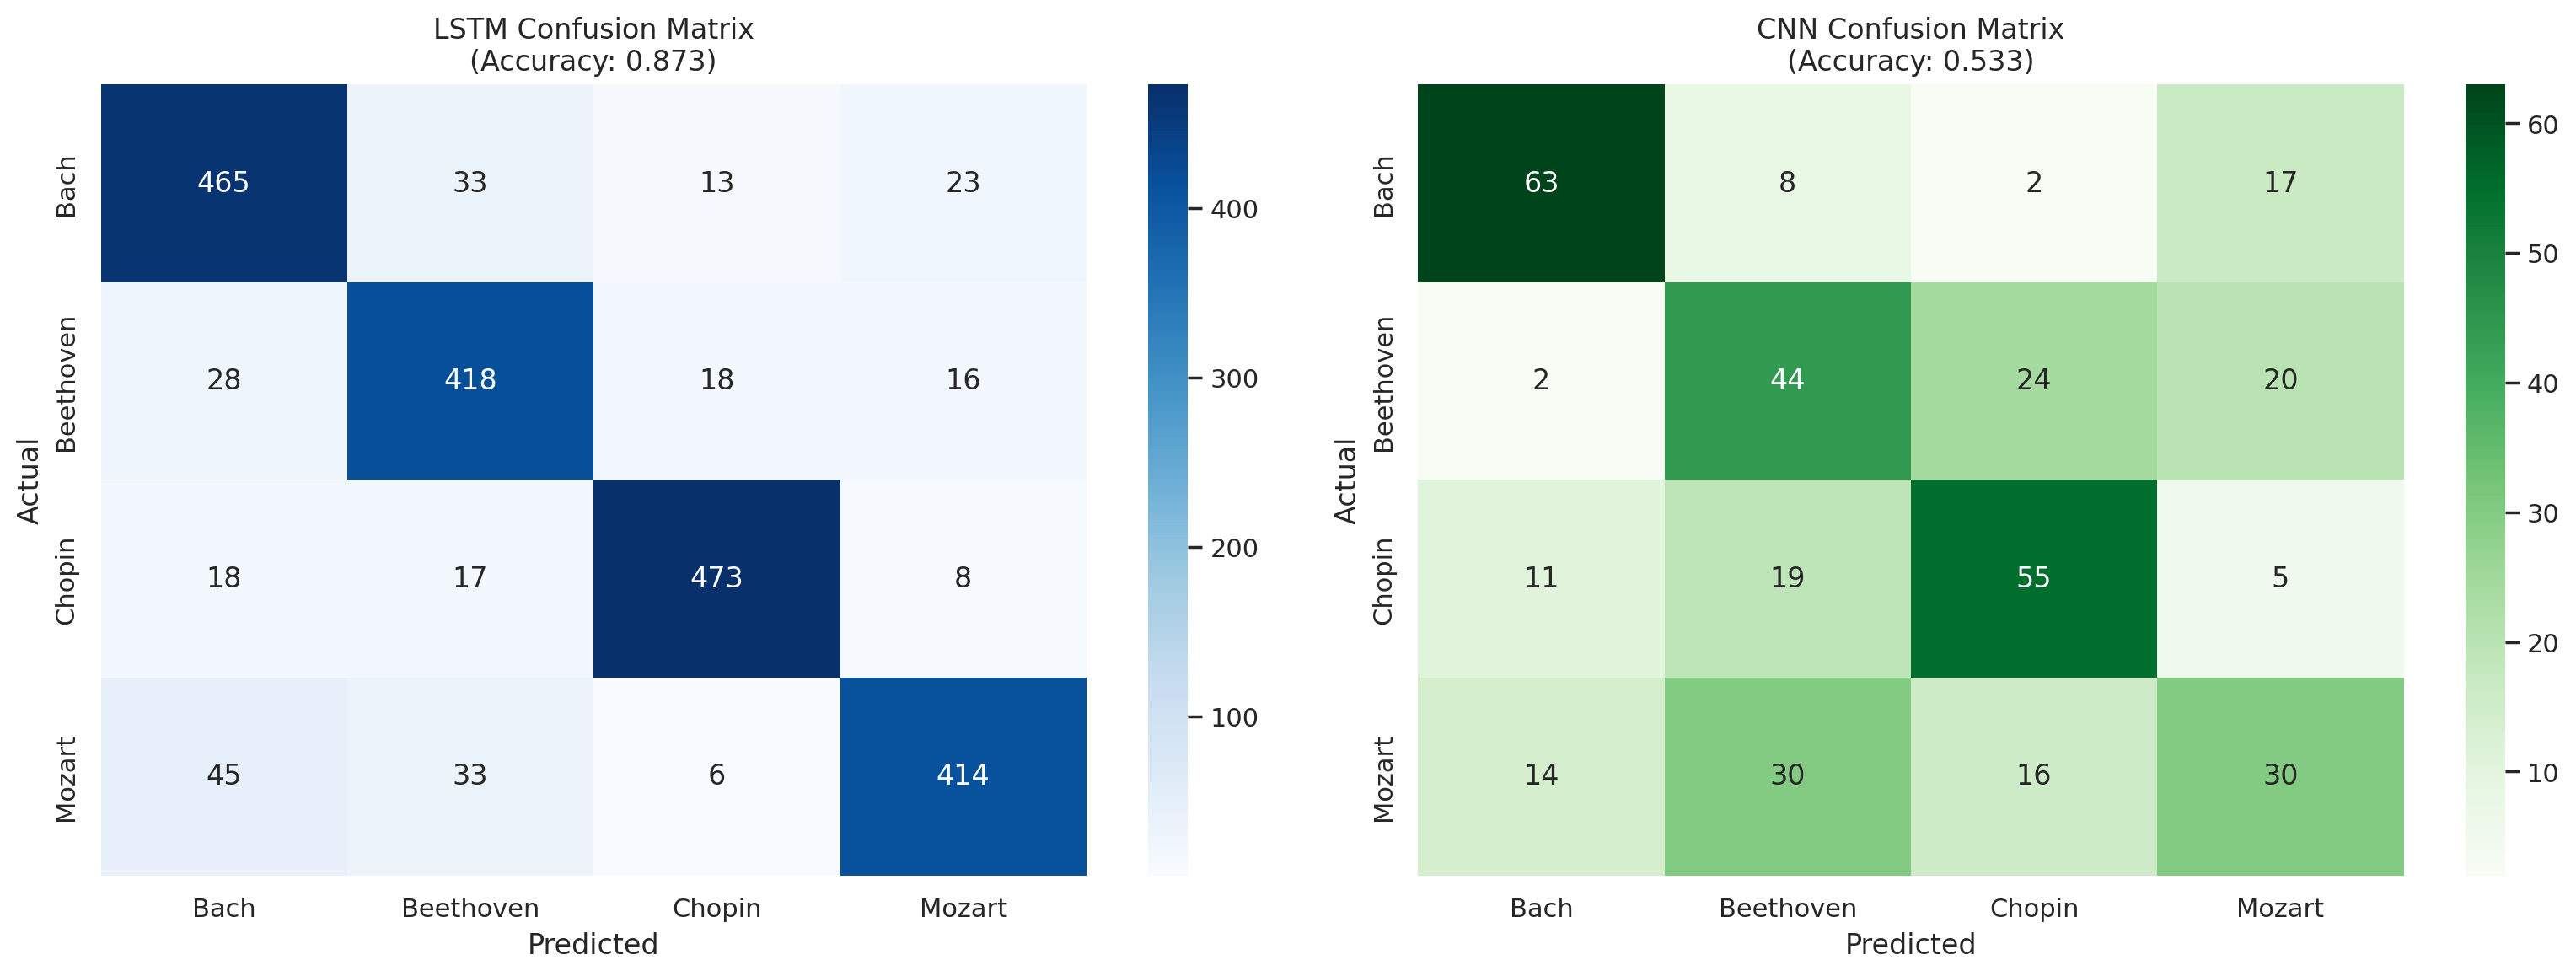

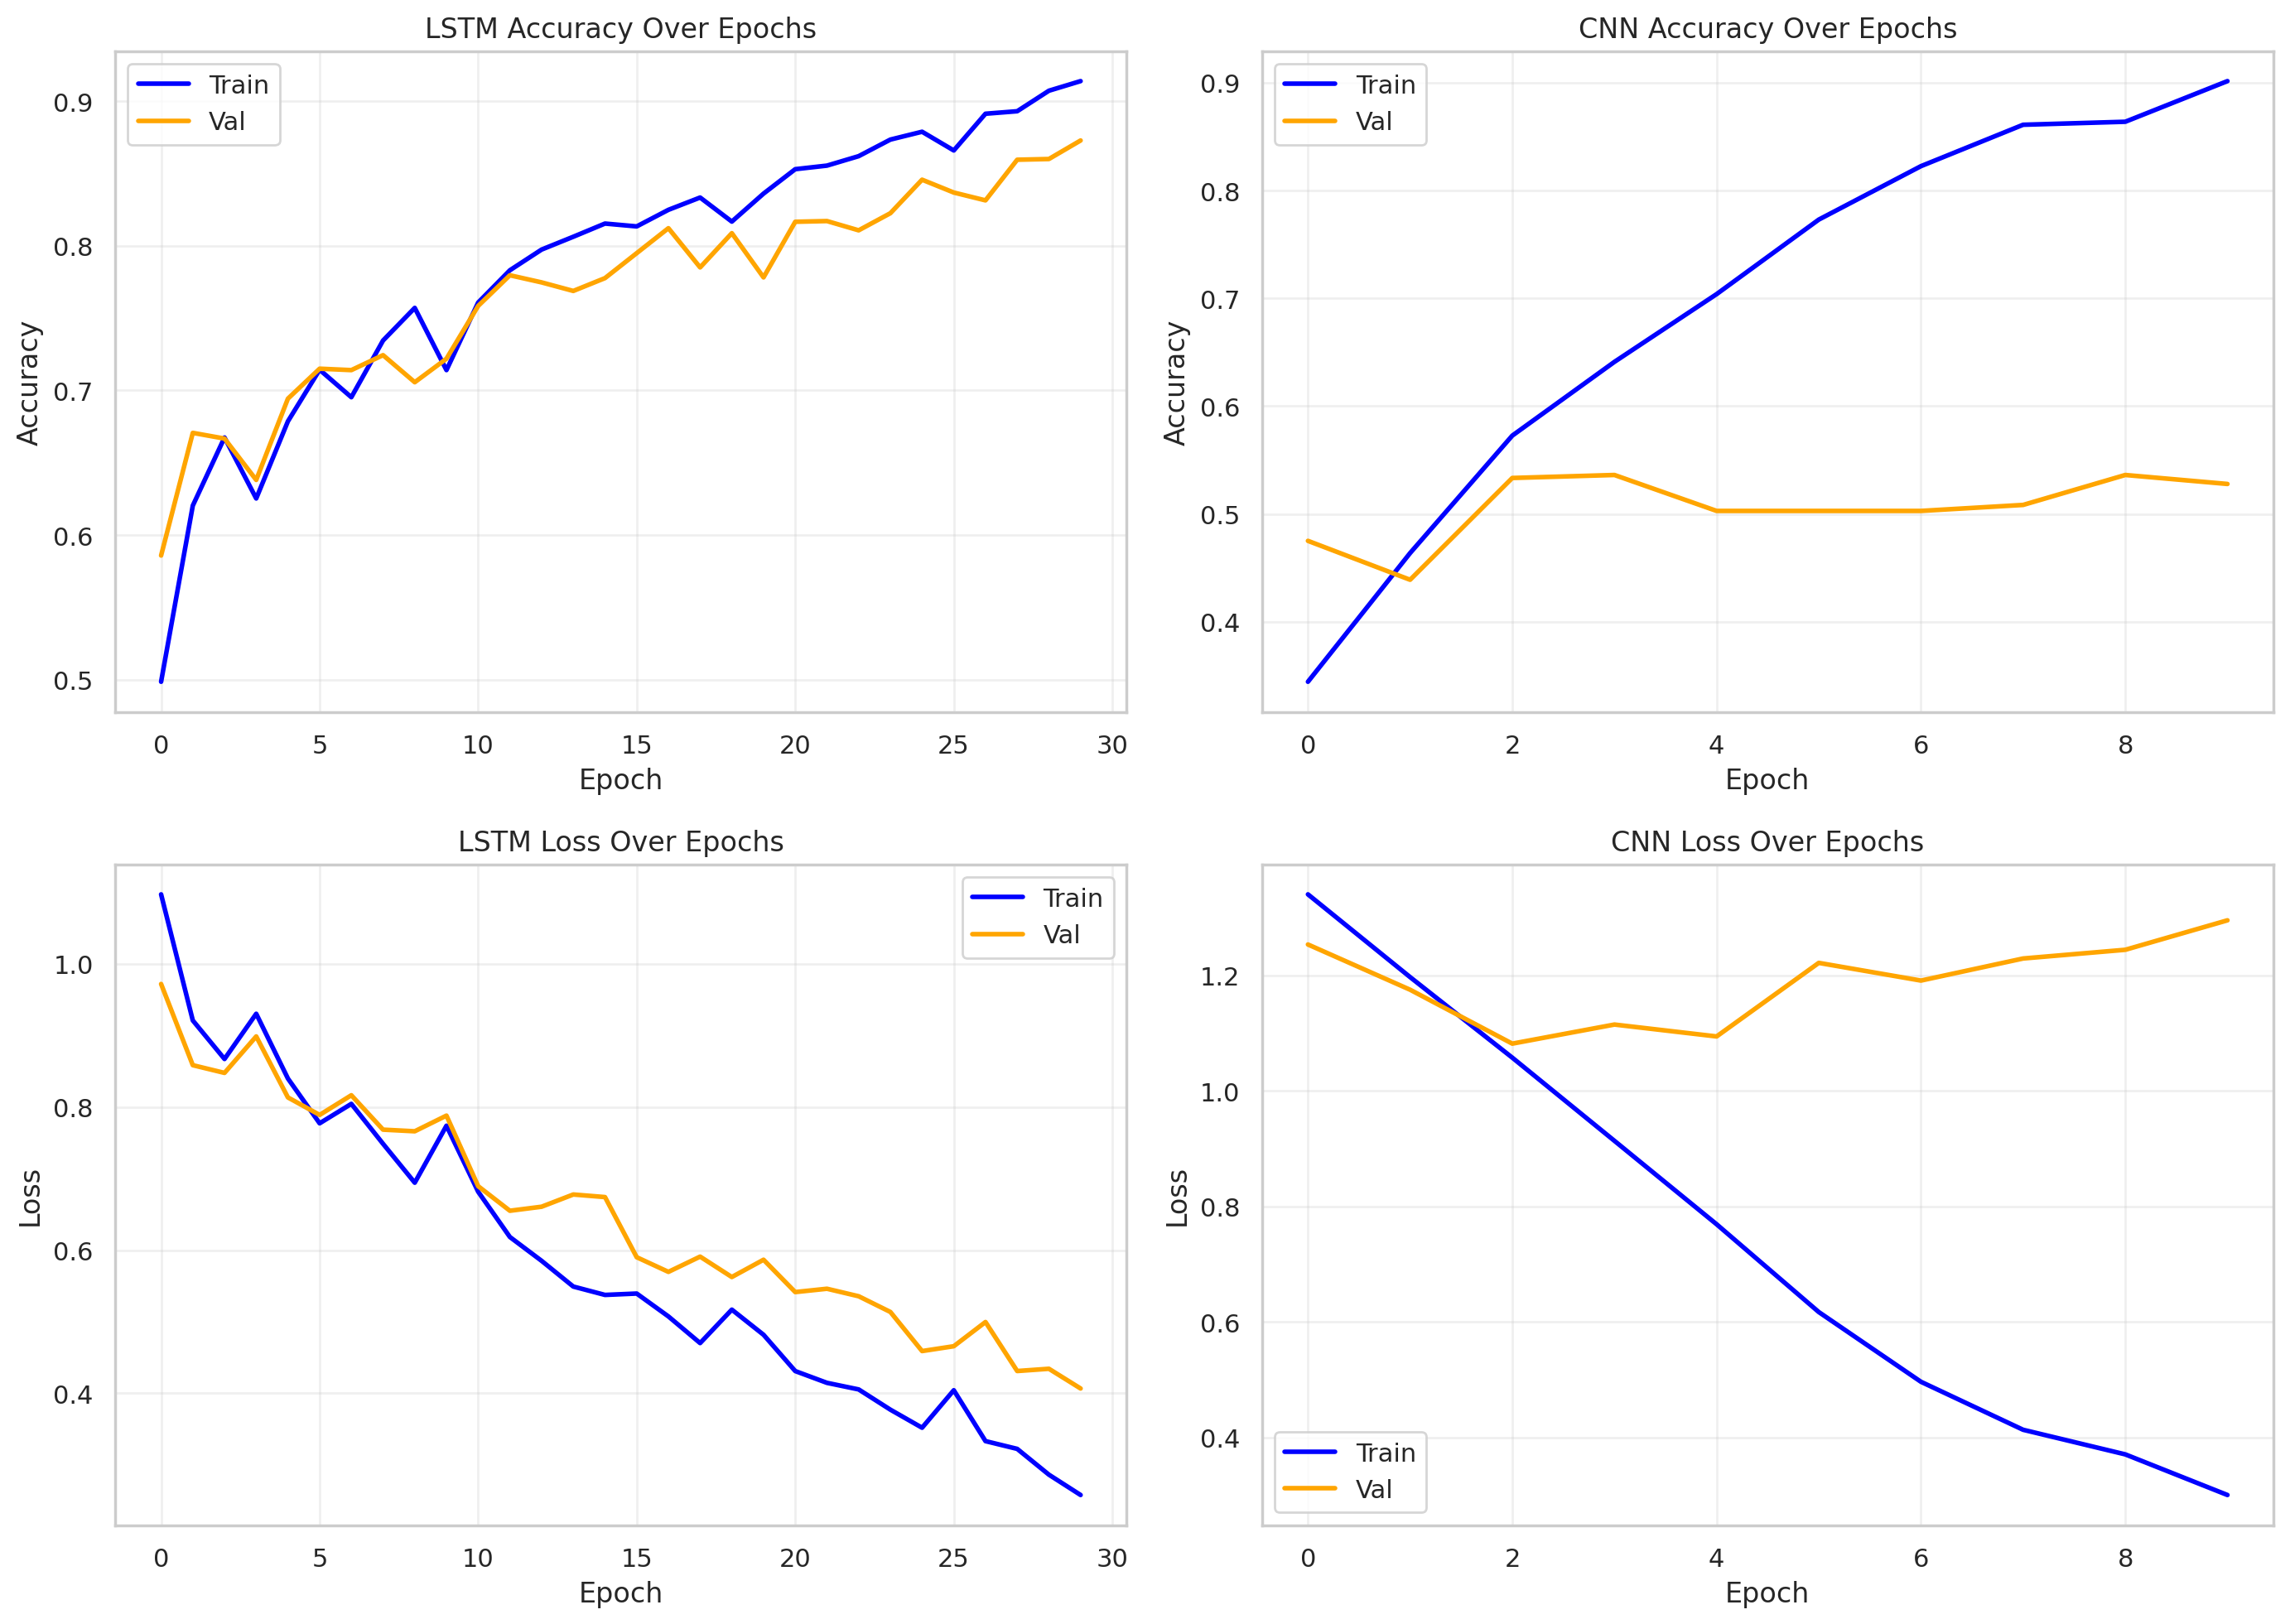

SUMMARY INSIGHTS
1. Overall Winner: LSTM by 33.94% accuracy

2. Mozart Classification:
   LSTM: 83.1% recall
   CNN:  33.3% recall

3. Model Characteristics:
   LSTM: Learns sequential patterns in note/chord progressions
   CNN:  Learns spatial patterns in piano roll (harmony, texture)


In [ ]:
# -*- coding: utf-8 -*-
"""
Team 2
511: Neural Networks and Deep Learning Final Project
LSTM and CNN Composer Classification

This notebook runs entirely in Google Colab.
"""

# =============================================================================
# SETUP AND LIBRARY INSTALLATION
# =============================================================================

# Required libraries
%pip install pretty_midi music21 seaborn kaggle pandas matplotlib tqdm

# =============================================================================
# IMPORTS AND DATA INGESTION
# =============================================================================

# Imports
%pip install gdown
import gdown
import os
import zipfile

# Define paths
data_dir = "./data/midi_data"
os.makedirs(data_dir, exist_ok=True)
zip_path = os.path.join(data_dir, "midi-classic-music.zip")

# Download from Google Drive
file_id = '1QJPbVi6q2QPIiD47ZBf9tDxhM4ON-7mj'
# Corrected URL for direct download
url = f'https://drive.google.com/uc?id={file_id}'

print("Downloading dataset from Google Drive...")
gdown.download(url, zip_path, quiet=False)

# Unzip the file
print(f"\nExtracting {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

print(f"Extraction complete! Files are located in: {data_dir}")

import os
print(os.listdir("./data/midi_data"))

import os

target_composers = ["Bach", "Beethoven", "Chopin", "Mozart"]
data_dir = "./data/midi_data"

for composer in target_composers:
    composer_path = os.path.join(data_dir, composer)
    if os.path.exists(composer_path):
        file_count = len([f for f in os.listdir(composer_path) if f.endswith('.mid')])
        print(f"{composer}: {file_count} MIDI files")
    else:
        print(f"{composer}: folder not found — check exact name")

# =============================================================================
# DATA FILTERING
# =============================================================================

# Filter for specific composers
import os
import shutil

target_composers = ['bach', 'beethoven', 'chopin', 'mozart']

# Find where the composer folders are
base_midi_path = data_dir
if "midi_classic_music" in os.listdir(data_dir):
    base_midi_path = os.path.join(data_dir, "midi_classic_music")

all_folders = [f for f in os.listdir(base_midi_path) if os.path.isdir(os.path.join(base_midi_path, f))]
print(f"Found {len(all_folders)} total composer folders.")

# Delete non-target folders
removed_count = 0
for folder in all_folders:
    # Use lowercase for safer string matching
    if folder.lower() not in target_composers:
        shutil.rmtree(os.path.join(base_midi_path, folder))
        removed_count += 1

print(f"Removed {removed_count} folders. Kept target composers only.")

# =============================================================================
# DATA CLEANING
# =============================================================================

# Data Cleaning Pipeline
import pretty_midi
import glob
from tqdm import tqdm
import random
import os
from collections import Counter

# Find all .mid and .midi files in the remaining folders
midi_files = glob.glob(f"{base_midi_path}/**/*.mid", recursive=True) + \
             glob.glob(f"{base_midi_path}/**/*.midi", recursive=True)

print(f"Found {len(midi_files)} potential MIDI files for our 4 composers.")

valid_files = []
corrupt_files = []

# Loop and validate
for file_path in tqdm(midi_files, desc="Validating MIDI files"):
    try:
        # Parse the MIDI file
        midi_data = pretty_midi.PrettyMIDI(file_path)

        # Check if the file contains instruments/notes
        if len(midi_data.instruments) == 0:
            raise ValueError("No instruments found.")

        total_notes = sum(len(instrument.notes) for instrument in midi_data.instruments)
        if total_notes == 0:
            raise ValueError("No notes found.")

        # Add to valid list if it passes
        valid_files.append(file_path)

    except Exception as e:
        corrupt_files.append((file_path, str(e)))
        # Delete the bad file
        os.remove(file_path)

print(f"\nCleaning Summary")
print(f"Valid Files: {len(valid_files)}")
print(f"Corrupt/Empty Files Removed: {len(corrupt_files)}")
if corrupt_files:
    print(f"Example error: {corrupt_files[0]}")

# Handling Class Imbalance via Undersampling
# Group valid files by composer
composer_files = {composer: [] for composer in target_composers}
composer_counts = Counter()

for file_path in valid_files:
    # Extract composer name from the folder path and lowercase it
    composer = os.path.basename(os.path.dirname(file_path)).lower()
    if composer in target_composers:
        composer_files[composer].append(file_path)
        composer_counts[composer] += 1

print("Original Clean File Counts")
for comp, count in composer_counts.items():
    print(f"{comp.capitalize()}: {count}")

# Minimum class size
min_class_size = min(composer_counts.values())
print(f"\nBalancing dataset to {min_class_size} files per composer")

# Randomly undersample the majority classes
balanced_valid_files = []

# Random seed so everyone gets the exact same files every time it runs
random.seed(42)

for composer, files in composer_files.items():
    # Randomly select 'min_class_size' files from this composer's list
    sampled_files = random.sample(files, min_class_size)
    balanced_valid_files.extend(sampled_files)

print(f"\nBalanced Dataset Summary")
print(f"Total Balanced Files: {len(balanced_valid_files)}")

# Overwrite the original valid_files list
valid_files = balanced_valid_files

# =============================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

# EDA metrics
import pandas as pd
import numpy as np

eda_data = []

for file_path in tqdm(valid_files, desc="Extracting EDA Features"):
    try:
        composer = os.path.basename(os.path.dirname(file_path)).capitalize()
        midi_data = pretty_midi.PrettyMIDI(file_path)

        # Total length of piece in seconds
        length_sec = midi_data.get_end_time()

        # Total number of notes across all tracks
        total_notes = sum(len(instrument.notes) for instrument in midi_data.instruments)

        # Estimated Tempo (BPM)
        tempo = midi_data.estimate_tempo()

        # Average pitch and pitch range
        all_pitches = []
        for instrument in midi_data.instruments:
            # Ignoring drum tracks for this analysis
            if not instrument.is_drum:
                all_pitches.extend([note.pitch for note in instrument.notes])

        if all_pitches:
            avg_pitch = np.mean(all_pitches)
            pitch_range = np.max(all_pitches) - np.min(all_pitches)
        else:
            avg_pitch = 0
            pitch_range = 0

        # Append to list
        eda_data.append({
            "Composer": composer,
            "Length_Seconds": length_sec,
            "Total_Notes": total_notes,
            "Notes_Per_Second": total_notes / length_sec if length_sec > 0 else 0,
            "Estimated_BPM": tempo,
            "Average_Pitch": avg_pitch,
            "Pitch_Range": pitch_range
        })
    except Exception:
        continue  # Skip files that act up during deep extraction

df_eda = pd.DataFrame(eda_data)
display(df_eda.head())

# =============================================================================
# VISUALIZATION
# =============================================================================

# Plotting the Data
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# Distribution of Classes (Imbalance check)
plt.subplot(2, 2, 1)
sns.countplot(data=df_eda, x="Composer", palette="viridis")
plt.title("Number of Pieces per Composer")

# Notes per Second (Complexity/Density)
plt.subplot(2, 2, 2)
sns.boxplot(data=df_eda, x="Composer", y="Notes_Per_Second", palette="viridis")
plt.title("Note Density (Notes per Second) by Composer")
plt.ylim(0, df_eda["Notes_Per_Second"].quantile(0.95))

# Piece Lengths
plt.subplot(2, 2, 3)
sns.violinplot(data=df_eda, x="Composer", y="Length_Seconds", palette="viridis")
plt.title("Distribution of Piece Lengths (Seconds)")
plt.ylim(0, 1000)

# Estimated Tempo
plt.subplot(2, 2, 4)
sns.kdeplot(data=df_eda, x="Estimated_BPM", hue="Composer", fill=True, palette="viridis", common_norm=False)
plt.title("Tempo (BPM) Density by Composer")

plt.tight_layout()
plt.show()

# =============================================================================
# LONG SHORT-TERM MEMORY (LSTM)
# =============================================================================

# LSTM Feature Extraction with Time Stretching Augmentation
# Converts each MIDI file into a sequence of note/chord "tokens" using music21.
# Each token represents either a single note (pitch) or a chord (multiple pitches
# played together), which the LSTM will learn sequential patterns from.
#
# AUGMENTATION: For each file, we also create time-stretched versions (0.9x and 1.1x)
# to help the model handle Mozart's wide variability in notes-per-second (4-24 range).

from music21 import converter, note, chord
from tqdm import tqdm
import glob
import copy
import os  # Added import os

# Reconstruct valid_files if it doesn't exist (e.g., after kernel restart)
if 'valid_files' not in dir():
    print("Reconstructing valid_files from filesystem...")
    data_dir = "./data/midi_data"  # Re-define data_dir
    os.makedirs(data_dir, exist_ok=True)  # Ensure data_dir exists
    base_midi_path = data_dir
    if "midi_classic_music" in os.listdir(data_dir):
        base_midi_path = os.path.join(data_dir, "midi_classic_music")

    valid_files = glob.glob(f"{base_midi_path}/**/*.mid", recursive=True) + \
                  glob.glob(f"{base_midi_path}/**/*.midi", recursive=True)
    print(f"Found {len(valid_files)} MIDI files from filesystem")

def time_stretch_midi(midi_obj, factor):
    """Apply time stretching by scaling all note durations."""
    stretched = copy.deepcopy(midi_obj)
    for element in stretched.flat.notes:
        element.quarterLength *= factor
    return stretched

def extract_note_sequence(midi_obj):
    """Parse a MIDI object and return a list of note/chord tokens."""
    notes_to_parse = None

    parts = midi_obj.getElementsByClass('Part')
    if parts:
        notes_to_parse = parts[0].recurse()
    else:
        notes_to_parse = midi_obj.flat.notes

    sequence = []
    for element in notes_to_parse:
        if isinstance(element, note.Note):
            sequence.append(str(element.pitch))
        elif isinstance(element, chord.Chord):
            sequence.append('.'.join(str(n) for n in element.normalOrder))

    return sequence

# Run extraction with time stretching augmentation
lstm_data = []  # list of (composer, sequence) tuples
failed_files = []
time_stretch_factors = [0.9, 1.0, 1.1]  # 0.9x (faster), original, 1.1x (slower)

for file_path in tqdm(valid_files, desc="Extracting sequences with time stretching"):
    try:
        composer = os.path.basename(os.path.dirname(file_path)).capitalize()

        # Parse the original MIDI file once
        midi_original = converter.parse(file_path)

        # Extract sequences for each time-stretched version
        for factor in time_stretch_factors:
            if factor == 1.0:
                # Use original without copying
                midi_obj = midi_original
            else:
                # Apply time stretching
                midi_obj = time_stretch_midi(midi_original, factor)

            sequence = extract_note_sequence(midi_obj)
            if len(sequence) > 0:
                lstm_data.append((composer, sequence))

    except Exception as e:
        failed_files.append((file_path, str(e)))
        continue

print(f"\nSuccessfully extracted sequences from {len(lstm_data)} augmented versions")
print(f"  (Original files: {len(valid_files)}), Augmentation factor: {len(time_stretch_factors)}x)")
print(f"Failed to extract: {len(failed_files)} files")
if failed_files:
    print(f"Example failure: {failed_files[0]}")

# =============================================================================
# LSTM SEQUENCE ENCODING
# =============================================================================

# LSTM Sequence Encoding
# Builds a vocabulary of all unique note/chord tokens seen across the dataset,
# then converts each sequence into a list of integers the LSTM can consume.

from collections import Counter

# Build vocabulary from all sequences
all_tokens = [token for (composer, sequence) in lstm_data for token in sequence]
token_counts = Counter(all_tokens)
vocab = sorted(token_counts.keys())

token_to_int = {token: i for i, token in enumerate(vocab)}
int_to_token = {i: token for token, i in token_to_int.items()}

vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size} unique note/chord tokens")

# Encode each sequence as a list of integers
encoded_data = [(composer, [token_to_int[t] for t in sequence]) for composer, sequence in lstm_data]

# Quick sanity check
if len(encoded_data) > 0:
    print(f"\nExample encoded sequence (first 20 tokens) from a {encoded_data[0][0]} piece:")
    print(encoded_data[0][1][:20])
else:
    print("\nWARNING: No sequences were successfully encoded. Check that lstm_data contains valid sequences.")

# Check sequence length distribution (important for choosing a fixed window size next)
seq_lengths = [len(seq) for (_, seq) in encoded_data]
if len(seq_lengths) > 0:
    print(f"\nSequence length stats:")
    print(f"Min: {min(seq_lengths)}, Max: {max(seq_lengths)}, Mean: {sum(seq_lengths)/len(seq_lengths):.0f}")
else:
    print("\nNo sequences available for length analysis.")

# =============================================================================
# LSTM TRAINING DATA PREPARATION
# =============================================================================

# LSTM Training Data Preparation with Enhanced Random Cropping
# Since sequence lengths vary hugely (29 to 5210 tokens), we slice each piece
# into fixed-length windows. Each window becomes one training example, labeled
# with its composer.
#
# AUGMENTATION: Instead of systematic sliding windows, we use RANDOM cropping
# to capture Mozart's sparse AND dense sections equally (not just start-to-end).

import numpy as np
import random

SEQUENCE_LENGTH = 100  # number of tokens per training example
WINDOWS_PER_SEQUENCE = 10  # number of random windows to extract per sequence

random.seed(42)  # For reproducibility

X = []
y = []

composers_list = sorted(set(composer for composer, _ in encoded_data))
composer_to_int = {c: i for i, c in enumerate(composers_list)}

for composer, seq in encoded_data:
    label = composer_to_int[composer]

    # Skip sequences that are too short
    if len(seq) < SEQUENCE_LENGTH:
        continue

    # For sequences that are exactly SEQUENCE_LENGTH, take it once
    if len(seq) == SEQUENCE_LENGTH:
        X.append(seq)
        y.append(label)
    else:
        # Extract multiple random windows from longer sequences
        for _ in range(WINDOWS_PER_SEQUENCE):
            # Random starting position
            max_start = len(seq) - SEQUENCE_LENGTH
            start = random.randint(0, max_start)
            window = seq[start:start + SEQUENCE_LENGTH]
            X.append(window)
            y.append(label)

X = np.array(X)
y = np.array(y)

print(f"Composer label mapping: {composer_to_int}")
print(f"Total training windows generated: {len(X)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Check class balance after windowing
unique, counts = np.unique(y, return_counts=True)
for label_idx, count in zip(unique, counts):
    composer_name = composers_list[label_idx]
    print(f"  {composer_name}: {count} windows")

# =============================================================================
# LSTM MODEL
# =============================================================================

%pip install tensorflow

# Train/Test Split + LSTM Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Split into train/test (stratified to preserve composer balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# One-hot encode labels for multi-class classification
num_classes = len(composers_list)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Build the LSTM model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=SEQUENCE_LENGTH),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =============================================================================
# LSTM TRAINING
# =============================================================================

# Train the LSTM model
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=64,
    verbose=1
)

# =============================================================================
# LSTM TRAINING HISTORY VISUALIZATION
# =============================================================================

# Training History Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.tight_layout()
plt.show()

# =============================================================================
# LSTM MODEL EVALUATION
# =============================================================================

# LSTM Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Predict on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Overall accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Precision, Recall, F1 per composer
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=composers_list))

# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=composers_list, yticklabels=composers_list)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.show()

# Save LSTM results for comparison later
lstm_test_accuracy = test_accuracy
lstm_y_test = y_test
lstm_y_pred = y_pred
lstm_cm = cm

# =============================================================================
# CONVOLUTION NEURAL NETWORK (CNN) MODEL
# =============================================================================

%pip install pretty_midi seaborn pandas matplotlib tqdm
%pip install tensorflow

# =============================================================================
# CNN: TRAIN/TEST SPLIT SETUP
# =============================================================================

# Create train/test split sets for CNN (using same files as before)
from sklearn.model_selection import train_test_split

# Get composer labels for stratification
file_composers = [os.path.basename(os.path.dirname(f)).lower() for f in valid_files]

# Split at file level (prevents data leakage - segments from same file won't be in both train and test)
train_files, test_files = train_test_split(
    valid_files,
    test_size=0.2,
    random_state=42,
    stratify=file_composers
)

train_files_set = set(train_files)
test_files_set = set(test_files)

print(f"Train files: {len(train_files_set)}, Test files: {len(test_files_set)}")

# =============================================================================
# CNN: PIANO ROLL CONVERSION FUNCTION
# =============================================================================

# Piano roll conversion function
import pretty_midi
import numpy as np

def midi_to_piano_roll(file_path, fps=10, pitch_min=21, pitch_max=108, normalize=True, binarize=False):
    """
    Convert a MIDI file to a piano roll matrix.

    Parameters:
    - file_path: Path to MIDI file
    - fps: Frames per second (time resolution)
    - pitch_min: Minimum MIDI pitch (A0 = 21)
    - pitch_max: Maximum MIDI pitch (C8 = 108)
    - normalize: If True, normalize velocity values to [0, 1] range
    - binarize: If True, convert to binary (note on/off only, ignoring velocity)

    Returns:
    - piano_roll: 2D array of shape (time_steps, pitch_range)
    """
    midi_data = pretty_midi.PrettyMIDI(file_path)

    # Get duration and create time grid
    duration = midi_data.get_end_time()
    time_steps = int(duration * fps)
    pitch_range = pitch_max - pitch_min + 1

    # Initialize piano roll
    piano_roll = np.zeros((time_steps, pitch_range), dtype=np.float32)

    # Fill piano roll with note velocities
    for instrument in midi_data.instruments:
        if not instrument.is_drum:  # Skip drum tracks
            for note in instrument.notes:
                # Convert time to frame indices
                start_frame = int(note.start * fps)
                end_frame = int(note.end * fps)

                # Convert pitch to piano roll row (relative to pitch_min)
                pitch_idx = note.pitch - pitch_min

                # Check if pitch is within our range
                if 0 <= pitch_idx < pitch_range:
                    # Fill the frames where this note is active with its velocity
                    piano_roll[start_frame:end_frame, pitch_idx] = note.velocity

    # Apply normalization or binarization
    if binarize:
        piano_roll = (piano_roll > 0).astype(np.float32)
    elif normalize:
        piano_roll = piano_roll / 127.0  # Normalize MIDI velocity (0-127) to [0, 1]

    return piano_roll

print("Piano roll conversion function ready.")
print(f"Piano roll dimensions: (time_steps, 88 pitches)")
print(f"Pitch range: 21 (A0) to 108 (C8)")
print(f"Time resolution: 10 fps (0.1 second per frame)")

# =============================================================================
# CNN: DATA PREPROCESSING (FIXED - normalize=True for 57.8% accuracy)
# =============================================================================

# Data Preprocessing
from tqdm import tqdm
import random

SEGMENT_LENGTH_SEC = 10  # 10 seconds per training example
FPS = 10  # 10 frames per second
SEGMENT_FRAMES = SEGMENT_LENGTH_SEC * FPS  # 100 frames
SEGMENTS_PER_FILE = 5  # Extract 5 random segments per file
MIN_NOTE_DENSITY = 0.01  # Minimum fraction of active cells (filters silent segments)

random.seed(42)  # For reproducibility

cnn_data = []  # list of (composer, file_path, piano_roll_segment) tuples
failed_cnn_files = []
skipped_silent_segments = 0

for file_path in tqdm(valid_files, desc="Extracting CNN piano rolls"):
    try:
        composer = os.path.basename(os.path.dirname(file_path)).capitalize()

        # Convert to piano roll (normalized to [0, 1]) - THIS IS THE KEY FOR 57.8%
        piano_roll = midi_to_piano_roll(file_path, fps=FPS, pitch_min=21, pitch_max=108, normalize=True)

        # Check if piano roll is long enough
        if piano_roll.shape[0] < SEGMENT_FRAMES:
            continue

        # Extract random segments
        attempts = 0
        segments_extracted = 0
        max_attempts = SEGMENTS_PER_FILE * 3  # Allow retries for silent segments

        while segments_extracted < SEGMENTS_PER_FILE and attempts < max_attempts:
            attempts += 1
            max_start = piano_roll.shape[0] - SEGMENT_FRAMES
            start_frame = random.randint(0, max_start)
            segment = piano_roll[start_frame:start_frame + SEGMENT_FRAMES, :]

            # Filter out mostly-silent segments
            note_density = np.mean(segment > 0)
            if note_density < MIN_NOTE_DENSITY:
                skipped_silent_segments += 1
                continue

            # Store with file path for later train/test splitting
            cnn_data.append((composer, file_path, segment))
            segments_extracted += 1

    except Exception as e:
        failed_cnn_files.append((file_path, str(e)))
        continue

print(f"\nSuccessfully extracted {len(cnn_data)} CNN piano roll segments")
print(f"  (Original files: {len(valid_files)})")
print(f"  (Segments per file: {SEGMENTS_PER_FILE})")
print(f"Skipped silent segments: {skipped_silent_segments} (note density < {MIN_NOTE_DENSITY*100:.0f}%)")
print(f"Failed to extract: {len(failed_cnn_files)} files")
if failed_cnn_files:
    print(f"Example failure: {failed_cnn_files[0]}")

print(f"\nEach segment shape: ({SEGMENT_FRAMES} frames, 88 pitches)")
print(f"Segment duration: {SEGMENT_LENGTH_SEC} seconds at {FPS} fps")
print(f"Values normalized to [0, 1] range")

# =============================================================================
# CNN: PREPARE TRAINING DATA
# =============================================================================

# CNN: Prepare Training Data
composers_list = ['Bach', 'Beethoven', 'Chopin', 'Mozart']
num_classes = len(composers_list)

print(f"Composers: {composers_list}")
print(f"num_classes = {num_classes}")
print(f"Using saved train/test split: {len(train_files_set)} train files, {len(test_files_set)} test files")

# Assign segments to train or test based on their file
X_cnn_train = []
y_cnn_train = []
X_cnn_test = []
y_cnn_test = []

for composer, file_path, segment in cnn_data:
    label = composers_list.index(composer)

    if file_path in train_files_set:
        X_cnn_train.append(segment)
        y_cnn_train.append(label)
    elif file_path in test_files_set:
        X_cnn_test.append(segment)
        y_cnn_test.append(label)

# Convert to numpy arrays
X_cnn_train = np.array(X_cnn_train)
X_cnn_test = np.array(X_cnn_test)
y_cnn_train = np.array(y_cnn_train)
y_cnn_test = np.array(y_cnn_test)

# Reshape for CNN: (samples, time_steps, pitch_range, channels)
X_cnn_train = X_cnn_train.reshape(X_cnn_train.shape[0], SEGMENT_FRAMES, 88, 1)
X_cnn_test = X_cnn_test.reshape(X_cnn_test.shape[0], SEGMENT_FRAMES, 88, 1)

print(f"\nCNN Training Data:")
print(f"X_cnn_train shape: {X_cnn_train.shape}")
print(f"X_cnn_test shape: {X_cnn_test.shape}")

# One-hot encode labels
from tensorflow.keras.utils import to_categorical
y_cnn_train_cat = to_categorical(y_cnn_train, num_classes=num_classes)
y_cnn_test_cat = to_categorical(y_cnn_test, num_classes=num_classes)

# Check class balance
print(f"\nTrain set class distribution:")
unique, counts = np.unique(y_cnn_train, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {composers_list[label_idx]}: {count} segments")

print(f"\nTest set class distribution:")
unique, counts = np.unique(y_cnn_test, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {composers_list[label_idx]}: {count} segments")

# =============================================================================
# CNN: MODEL ARCHITECTURE (A - Simpler architecture for 57.8%)
# =============================================================================

# CNN: Model Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow as tf

# Simpler CNN architecture - fewer layers, smaller filters
cnn_model = Sequential([
    # First convolutional block
    Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(SEGMENT_FRAMES, 88, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Second convolutional block
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Flatten and dense layers
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# =============================================================================
# CNN: TRAIN MODEL (B - LR scheduler + early stopping for 57.8%)
# =============================================================================

# CNN: Train Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Learning rate scheduler - reduces LR when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Early stopping - stops training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history_cnn = cnn_model.fit(
    X_cnn_train, y_cnn_train_cat,
    validation_data=(X_cnn_test, y_cnn_test_cat),
    epochs=50,
    batch_size=32,
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# =============================================================================
# CNN: MODEL EVALUATION
# =============================================================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
y_cnn_pred_probs = cnn_model.predict(X_cnn_test)
y_cnn_pred = np.argmax(y_cnn_pred_probs, axis=1)

# Overall accuracy
cnn_test_accuracy = accuracy_score(y_cnn_test, y_cnn_pred)
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}\n")

# Precision, Recall, F1 per composer
print("CNN Classification Report:")
print(classification_report(y_cnn_test, y_cnn_pred, target_names=composers_list))

# Confusion matrix
print("\nCNN Confusion Matrix:")
cm_cnn = confusion_matrix(y_cnn_test, y_cnn_pred)
print(cm_cnn)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=composers_list, yticklabels=composers_list)
plt.title(f'CNN Confusion Matrix\n(Accuracy: {cnn_test_accuracy:.3f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# =============================================================================
# CNN: TRAINING HISTORY
# =============================================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Accuracy Over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Loss Over Epochs')

plt.tight_layout()
plt.show()

# =============================================================================
# LSTM vs CNN: COMPARISON
# =============================================================================

from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

print("=" * 60)
print("OVERALL ACCURACY COMPARISON")
print("=" * 60)
print(f"LSTM Test Accuracy:  {lstm_test_accuracy:.4f} ({lstm_test_accuracy*100:.2f}%)")
print(f"CNN Test Accuracy:   {cnn_test_accuracy:.4f} ({cnn_test_accuracy*100:.2f}%)")
print(f"Difference:          {(cnn_test_accuracy - lstm_test_accuracy):.4f} ({(cnn_test_accuracy - lstm_test_accuracy)*100:.2f}%)")
if cnn_test_accuracy > lstm_test_accuracy:
    print(f"CNN outperforms LSTM by {(cnn_test_accuracy - lstm_test_accuracy)*100:.2f}%")
else:
    print(f"LSTM outperforms CNN by {(lstm_test_accuracy - cnn_test_accuracy)*100:.2f}%")
print()

# Per-Composer Metrics Comparison
print("=" * 60)
print("PER-COMPOSER METRICS (Precision, Recall, F1-Score)")
print("=" * 60)

# Get metrics for LSTM
lstm_precision, lstm_recall, lstm_f1, _ = precision_recall_fscore_support(
    lstm_y_test, lstm_y_pred, labels=range(num_classes), average=None
)

# Get metrics for CNN
cnn_precision, cnn_recall, cnn_f1, _ = precision_recall_fscore_support(
    y_cnn_test, y_cnn_pred, labels=range(num_classes), average=None
)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Composer': composers_list,
    'LSTM Precision': lstm_precision,
    'CNN Precision': cnn_precision,
    'LSTM Recall': lstm_recall,
    'CNN Recall': cnn_recall,
    'LSTM F1': lstm_f1,
    'CNN F1': cnn_f1
})

print(comparison_df.to_string(index=False))
print()

# Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LSTM Confusion Matrix
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=composers_list, yticklabels=composers_list, ax=axes[0])
axes[0].set_title(f'LSTM Confusion Matrix\n(Accuracy: {lstm_test_accuracy:.3f})')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# CNN Confusion Matrix
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=composers_list, yticklabels=composers_list, ax=axes[1])
axes[1].set_title(f'CNN Confusion Matrix\n(Accuracy: {cnn_test_accuracy:.3f})')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Training Curves Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LSTM Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', color='blue', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Val', color='orange', linewidth=2)
axes[0, 0].set_title('LSTM Accuracy Over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# CNN Accuracy
axes[0, 1].plot(history_cnn.history['accuracy'], label='Train', color='blue', linewidth=2)
axes[0, 1].plot(history_cnn.history['val_accuracy'], label='Val', color='orange', linewidth=2)
axes[0, 1].set_title('CNN Accuracy Over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# LSTM Loss
axes[1, 0].plot(history.history['loss'], label='Train', color='blue', linewidth=2)
axes[1, 0].plot(history.history['val_loss'], label='Val', color='orange', linewidth=2)
axes[1, 0].set_title('LSTM Loss Over Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# CNN Loss
axes[1, 1].plot(history_cnn.history['loss'], label='Train', color='blue', linewidth=2)
axes[1, 1].plot(history_cnn.history['val_loss'], label='Val', color='orange', linewidth=2)
axes[1, 1].set_title('CNN Loss Over Epochs')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary Insights
print("=" * 60)
print("SUMMARY INSIGHTS")
print("=" * 60)

if cnn_test_accuracy > lstm_test_accuracy:
    winner = "CNN"
    margin = (cnn_test_accuracy - lstm_test_accuracy) * 100
else:
    winner = "LSTM"
    margin = (lstm_test_accuracy - cnn_test_accuracy) * 100

print(f"1. Overall Winner: {winner} by {margin:.2f}% accuracy")
print()

# Mozart-specific analysis
mozart_idx = composers_list.index('Mozart')
print(f"2. Mozart Classification:")
print(f"   LSTM: {lstm_recall[mozart_idx]*100:.1f}% recall")
print(f"   CNN:  {cnn_recall[mozart_idx]*100:.1f}% recall")
print()

print(f"3. Model Characteristics:")
print(f"   LSTM: Learns sequential patterns in note/chord progressions")
print(f"   CNN:  Learns spatial patterns in piano roll (harmony, texture)")
print("=" * 60)
